# Analisis Exploratorio de los datos

## Importacion de librerias

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from itertools import combinations
from scipy.stats import shapiro, normaltest, kstest,f_oneway, kruskal, chi2_contingency, levene

In [2]:
import warnings
warnings.filterwarnings('ignore')

## Cargado de datos desde la red

In [3]:
df_url='https://docs.google.com/spreadsheets/d/1NJiaIRABEh1mJrqzP6bAYBkhBruBwUUzplHdXViv9-g/export?format=csv'
df=pd.read_csv(df_url)

In [4]:
df.head()

,Patient_ID,Age,Gender,Country,Ethnicity,Family_History,Radiation_Exposure,Iodine_Deficiency,Smoking,Obesity,Diabetes,TSH_Level,T3_Level,T4_Level,Nodule_Size,Thyroid_Cancer_Risk,Diagnosis
0,1,66,Male,Russia,Caucasian,No,Yes,No,No,No,No,9.37,1.67,6.16,1.08,Low,Benign
1,2,29,Male,Germany,Hispanic,No,Yes,No,No,No,No,1.83,1.73,10.54,4.05,Low,Benign
2,3,86,Male,Nigeria,Caucasian,No,No,No,No,No,No,6.26,2.59,10.57,4.61,Low,Benign
3,4,75,Female,India,Asian,No,No,No,No,No,No,4.10,2.62,11.04,2.46,Medium,Benign
4,5,35,Female,Germany,African,Yes,Yes,No,No,No,No,9.10,2.11,10.71,2.11,High,Benign


## Funciones usadas

Funciones a utilizar en este proyecto

In [5]:
def Summary(data, sheet):
    print(f"Hoja: {sheet}")

    # Crear la tabla de resumen
    resumen = {
        "Cantidad de filas": data.shape[0],
        "Cantidad de columnas": data.shape[1],
        "Datos faltantes": data.isnull().sum().sum(),
        "Filas duplicadas": data.duplicated().sum()
    }

    # Convertir el resumen en un DataFrame
    ResumenHoja = pd.DataFrame(resumen, index=["Resumen"])
    print("\nResumen:")
    display(ResumenHoja)

    print("\nEncabezado:")
    display(data.head())

In [6]:
def graficar_distribuciones(df, columnas, bins=30):
    sns.set(style="whitegrid", palette="muted")
    n = len(columnas)
    
    fig, axes = plt.subplots(nrows=n, ncols=2, figsize=(12, 4*n))
    
    for i, col in enumerate(columnas):
        # Histograma con KDE
        sns.histplot(data=df, x=col, kde=True, bins=bins, ax=axes[i,0], color="skyblue")
        axes[i,0].set_title(f"Histograma de {col}", fontsize=12)
        axes[i,0].set_xlabel("")
        axes[i,0].set_ylabel("Frecuencia")
        
        # Boxplot
        sns.boxplot(data=df, x=col, ax=axes[i,1], color="lightcoral")
        axes[i,1].set_title(f"Boxplot de {col}", fontsize=12)
        axes[i,1].set_xlabel("")
    
    plt.suptitle("Distribuciones de variables numéricas", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

In [7]:
def graficar_categoricas(df,cat):
    for col  in cat:
        df[col].value_counts()
        sns.countplot(data=df, x=col, order=df[col].value_counts().index)
        plt.title(f'Distribución de {col}')
        plt.xticks(rotation=45)
        plt.show()

In [8]:
def prueba_normalidad(df, alpha=0.05):
    resultados = []

    # Detectar variables numéricas
    numericas = df.select_dtypes(include=[np.number]).columns.drop('Patient_ID')

    for col in numericas:
        serie = df[col].dropna()

        if len(serie) < 8:  # muy pocas muestras → no confiable
            resultados.append({
                "variable": col,
                "n_muestras": len(serie),
                "shapiro_p": np.nan,
                "dagostino_p": np.nan,
                "ks_p": np.nan,
                "es_normal (alpha=0.05)": "Muestra insuficiente"
            })
            continue

        # Shapiro-Wilk (solo si n <= 5000, más grande no recomendado)
        stat_shapiro, p_shapiro = shapiro(serie) if len(serie) <= 5000 else (np.nan, np.nan)

        # D’Agostino y Pearson
        stat_dagostino, p_dagostino = normaltest(serie)

        # Kolmogorov-Smirnov contra normal estándar
        stat_ks, p_ks = kstest(
            (serie - serie.mean()) / serie.std(ddof=0), 'norm'
        )

        # Veredicto final
        es_normal = (
            (np.isnan(p_shapiro) or p_shapiro > alpha) and
            (p_dagostino > alpha) and
            (p_ks > alpha)
        )

        resultados.append({
            "variable": col,
            "n_muestras": len(serie),
            "shapiro_p": p_shapiro,
            "dagostino_p": p_dagostino,
            "ks_p": p_ks,
            "es_normal (alpha=0.05)": es_normal
        })

    return pd.DataFrame(resultados).sort_values(by="es_normal (alpha=0.05)", ascending=False)

In [9]:
def analisis_bivariado_numerico(df, top=5, mostrar_graficos=True):
    # Seleccionar solo las columnas numéricas
    num_df = df.select_dtypes(include=[np.number])
    cols = num_df.columns.drop('Patient_ID')

    if len(cols) < 2:
        raise ValueError("Se necesitan al menos dos variables numéricas para el análisis bivariado.")
    
    resultados = []

    # Calcular correlaciones entre todas las parejas posibles
    for var1, var2 in combinations(cols, 2):
        valid_data = num_df[[var1, var2]].dropna()  
        pearson = valid_data[var1].corr(valid_data[var2], method='pearson')
        spearman = valid_data[var1].corr(valid_data[var2], method='spearman')
        covarianza = np.cov(valid_data[var1], valid_data[var2])[0, 1]

        resultados.append({
        'Variable 1': var1,
        'Variable 2': var2,
        'Correlación Pearson': pearson,
        'Correlación Spearman': spearman,
        'Covarianza': covarianza
        })
    
    corr_df = pd.DataFrame(resultados).sort_values(by='Correlación Spearman', ascending=False)
    
    print("===  Correlaciones más altas ===")
    display(corr_df.head(top))
    print("\n=== Correlaciones más bajas ===")
    display(corr_df.tail(top))

    # Gráficos opcionales para las correlaciones más altas y más bajas
    if mostrar_graficos:
        pares_altas = corr_df.head(top)
        pares_bajas = corr_df.tail(top)
        pares_interes = pd.concat([pares_altas, pares_bajas])

        for _, row in pares_interes.iterrows():
            var1, var2 = row['Variable 1'], row['Variable 2']
            plt.figure(figsize=(6,5))
            sns.regplot(x=var1, y=var2, data=num_df, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
            plt.title(f"{var1} vs {var2}\nCorrelación Spearman: {row['Correlación Spearman']:.3f}")
            plt.show()
    
    return corr_df

In [10]:
def analisis_bivariado_categorico(df, top=5, mostrar_graficos=True, grafico='heatmap'):
    # Filtrar solo variables categóricas
    cat_df = df.select_dtypes(include=['object', 'category'])
    cols = cat_df.columns.tolist()

    if len(cols) < 2:
        raise ValueError("Se necesitan al menos dos variables categóricas para el análisis bivariado.")

    resultados = []

    # Iterar sobre todas las combinaciones posibles de variables categóricas
    for var1, var2 in combinations(cols, 2):
        # Crear tabla de contingencia
        tabla = pd.crosstab(df[var1], df[var2])

        # Evitar tablas muy pequeñas
        if tabla.shape[0] < 2 or tabla.shape[1] < 2:
            continue

        # Prueba Chi-cuadrado
        chi2, p, dof, expected = chi2_contingency(tabla)

        # Calcular V de Cramer
        n = tabla.sum().sum()
        phi2 = chi2 / n
        r, k = tabla.shape
        phi2corr = max(0, phi2 - ((k - 1)*(r - 1)) / (n - 1))
        rcorr = r - ((r - 1)**2) / (n - 1)
        kcorr = k - ((k - 1)**2) / (n - 1)
        cramer_v = np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1))) if min(kcorr, rcorr) > 1 else 0

        resultados.append({
            'Variable 1': var1,
            'Variable 2': var2,
            'Chi-cuadrado': chi2,
            'Grados de libertad': dof,
            'Valor p': p,
            'V de Cramer': cramer_v
        })

    # Convertir resultados a DataFrame
    resumen_df = pd.DataFrame(resultados).sort_values(by='Valor p', ascending=True).reset_index(drop=True)

    if resumen_df.empty:
        print("No se encontraron combinaciones categóricas válidas.")
        return resumen_df

    # Mostrar top relaciones significativas
    print("=== Relaciones categóricas más significativas (menor valor p) ===")
    display(resumen_df.head(top))

    print("\n=== Relaciones menos significativas ===")
    display(resumen_df.tail(top))

    # Graficar top relaciones más significativas
    if mostrar_graficos:
        print("\nGráficos de las relaciones más significativas:")
        top_pairs = resumen_df.head(top)

        for _, row in top_pairs.iterrows():
            var1, var2 = row['Variable 1'], row['Variable 2']
            print(f"\n{var1} vs {var2} (p = {row['Valor p']:.4f}, V de Cramer = {row['V de Cramer']:.3f})")

            # Normalizar por filas para mostrar proporciones
            tabla_rel = pd.crosstab(df[var1], df[var2], normalize='index')

            plt.figure(figsize=(7, 5))
            if grafico == 'heatmap':
                sns.heatmap(tabla_rel, annot=True, cmap='YlGnBu', fmt=".2f")
                plt.title(f"{var1} vs {var2}\n(p = {row['Valor p']:.4f}, V = {row['V de Cramer']:.3f})")
                plt.xlabel(var2)
                plt.ylabel(var1)
                plt.tight_layout()
                plt.show()

    return resumen_df

In [11]:
def analisis_bivariado_cat_num(df, categoricas=None, numericas=None, mostrar_graficos=True):
    if categoricas is None:
        categoricas = df.select_dtypes(include=['object', 'category']).columns.tolist()
    if numericas is None:
        numericas = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

    resultados = []

    for cat in categoricas:
        for num in numericas:
            grupos = [df[num][df[cat] == nivel].dropna() for nivel in df[cat].dropna().unique()]
            grupos = [g for g in grupos if len(g) > 1]
            if len(grupos) < 2:
                continue

            # ==== NORMALIDAD (Kolmogorov-Smirnov) ====
            normalidades = []
            for g in grupos:
                # Estandarizamos los datos para comparar contra N(0,1)
                g_std = (g - np.mean(g)) / np.std(g, ddof=1)
                _, p_norm = kstest(g_std, 'norm')
                normalidades.append(p_norm > 0.05)

            # ==== HOMOCEDASTICIDAD (Levene) ====
            stat_lev, p_levene = levene(*grupos)
            homocedasticas = p_levene > 0.05

            # ==== ELECCIÓN DE PRUEBA ====
            if all(normalidades) and homocedasticas:
                prueba = "ANOVA"
                stat, p_valor = f_oneway(*grupos)
            else:
                prueba = "Kruskal-Wallis"
                stat, p_valor = kruskal(*grupos)

            resultados.append({
                'Categórica': cat,
                'Numérica': num,
                'Prueba': prueba,
                'Normalidad_OK': all(normalidades),
                'Homocedasticidad_OK': homocedasticas,
                'p-Levene': p_levene,
                'Estadístico': stat,
                'p-valor': p_valor
            })

            # ==== GRÁFICO ====
            if mostrar_graficos:
                plt.figure(figsize=(8, 6))
                sns.boxplot(x=cat, y=num, hue=cat, data=df, palette="Set2", legend=False)
                plt.title(f'{num} por {cat}\n({prueba}, p={p_valor:.4f})')
                plt.xticks(rotation=45,ha='right')
                plt.tight_layout()
                plt.show()

    return pd.DataFrame(resultados)

In [12]:
def comparacion_numericas_target(df, target):
    num_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop(target, errors="ignore")

    for col in num_cols:
        print(f"\n===== Análisis bivariado: {col} vs {target} =====\n")
        
        # Boxplot
        plt.figure(figsize=(6,4))
        sns.boxplot(data=df, x=target, y=col)
        plt.title(f"{col} vs {target} (Boxplot)")
        plt.show()

In [13]:
def comparacion_categoricas_target(df, target):
    cat_cols = df.select_dtypes(include=['object', 'category']).columns.drop(target, errors="ignore")

    for col in cat_cols:
        print(f"\n===== Análisis bivariado: {col} vs {target} =====\n")
        tabla = pd.crosstab(df[col], df[target])
        print("Frecuencias absolutas:\n", tabla)
        print("\nFrecuencias relativas (%):\n", 
              tabla.div(tabla.sum(axis=1), axis=0).round(2))
        plt.figure(figsize=(6,4))
        sns.countplot(data=df, x=col, hue=target)
        plt.title(f"{col} vs {target}")
        plt.xticks(rotation=30)
        plt.show()
        plt.figure(figsize=(6,4))
        sns.heatmap(tabla, annot=True, fmt="d", cmap="Blues")
        plt.title(f"Heatmap {col} vs {target}")
        plt.show()

In [14]:
# Función para calcular Cramér's V
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - (k-1)*(r-1)/(n-1))    
    rcorr = r - (r-1)**2/(n-1)
    kcorr = k - (k-1)**2/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

In [15]:
# Función para crear la matriz de correlación categórica
def categorical_corr_matrix(df):
    cat_cols = df.select_dtypes(include=['object', 'category']).columns
    n = len(cat_cols)
    corr_matrix = pd.DataFrame(np.zeros((n, n)), index=cat_cols, columns=cat_cols)

    for i in range(n):
        for j in range(i, n):
            v = cramers_v(df[cat_cols[i]], df[cat_cols[j]])
            corr_matrix.iloc[i, j] = v
            corr_matrix.iloc[j, i] = v
    return corr_matrix

## Analisis general del dataset

In [16]:
Summary(df,'Datos pacientes')

Hoja: Datos pacientes

Resumen:


,Cantidad de filas,Cantidad de columnas,Datos faltantes,Filas duplicadas
Resumen,212691,17,0,0



Encabezado:


,Patient_ID,Age,Gender,Country,Ethnicity,Family_History,Radiation_Exposure,Iodine_Deficiency,Smoking,Obesity,Diabetes,TSH_Level,T3_Level,T4_Level,Nodule_Size,Thyroid_Cancer_Risk,Diagnosis
0,1,66,Male,Russia,Caucasian,No,Yes,No,No,No,No,9.37,1.67,6.16,1.08,Low,Benign
1,2,29,Male,Germany,Hispanic,No,Yes,No,No,No,No,1.83,1.73,10.54,4.05,Low,Benign
2,3,86,Male,Nigeria,Caucasian,No,No,No,No,No,No,6.26,2.59,10.57,4.61,Low,Benign
3,4,75,Female,India,Asian,No,No,No,No,No,No,4.10,2.62,11.04,2.46,Medium,Benign
4,5,35,Female,Germany,African,Yes,Yes,No,No,No,No,9.10,2.11,10.71,2.11,High,Benign


 ## Resumen general de la hoja "Datos pacientes" 
 El dataset contiene 212,691 filas y 17 columnas.
 No se encontraron valores faltantes ni filas duplicadas, lo que evita la necesidad
 de aplicar limpieza básica como eliminación o imputación de datos.
 Estos datos están listos para análisis exploratorio o preparación para modelos ML.

 ## Encabezado del dataset 
 Las primeras filas muestran variables demográficas (Age, Gender, Country, Ethnicity),
 historial clínico (Family_History, Radiation_Exposure, Iodine_Deficiency, Smoking,
 Obesity, Diabetes) y mediciones hormonales (TSH_Level, T3_Level, T4_Level).
 También se incluye Nodule_Size y una etiqueta de riesgo (Thyroid_Cancer_Risk),
 además de la variable objetivo Diagnosis (Benign o Malignant).
 Este conjunto de características combina variables categóricas y numéricas,
 ideal para modelos supervisados de clasificación orientados a diagnóstico clínico.

In [17]:
df.describe()

,Patient_ID,Age,TSH_Level,T3_Level,T4_Level,Nodule_Size
count,212691.00000,212691.000000,212691.000000,212691.000000,212691.000000,212691.000000
mean,106346.00000,51.918497,5.045102,2.001727,8.246204,2.503403
std,61398.74739,21.632815,2.860264,0.866248,2.164188,1.444631
min,1.00000,15.000000,0.100000,0.500000,4.500000,0.000000
25%,53173.50000,33.000000,2.570000,1.250000,6.370000,1.250000
50%,106346.00000,52.000000,5.040000,2.000000,8.240000,2.510000
75%,159518.50000,71.000000,7.520000,2.750000,10.120000,3.760000
max,212691.00000,89.000000,10.000000,3.500000,12.000000,5.000000


In [18]:
df.Thyroid_Cancer_Risk.value_counts()

Thyroid_Cancer_Risk
Low       108388
Medium     72400
High       31903
Name: count, dtype: int64

Como podemos ver esta distribución muestra un claro desbalance entre clases, ya que la mayoría
de los pacientes se concentran en los niveles Low y Medium.
La categoría High es significativamente menor (~15% del total), lo cual sera
importante para el modelado

In [19]:
sns.set_style("whitegrid")

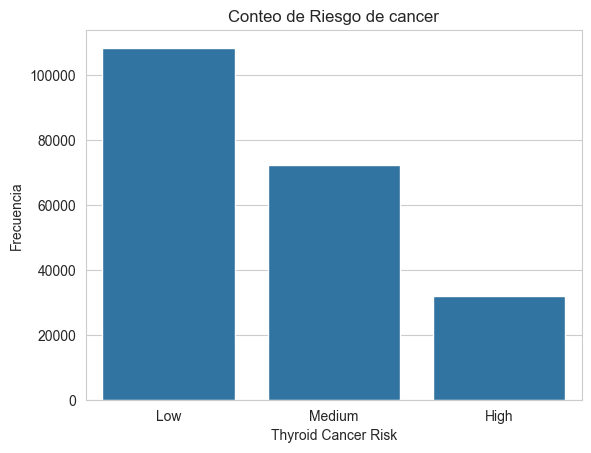

In [20]:
plt.title('Conteo de Riesgo de cancer')
sns.countplot(x=df.Thyroid_Cancer_Risk)
plt.xlabel('Thyroid Cancer Risk')
plt.ylabel('Frecuencia')
plt.show()

podemos observar que el dataset esta desbalanceado, tomaremos en cuenta esto mas adelante

## Analisis univariado

realizamod el analisis univariado mostrando las graficas de numericas y categoricas 

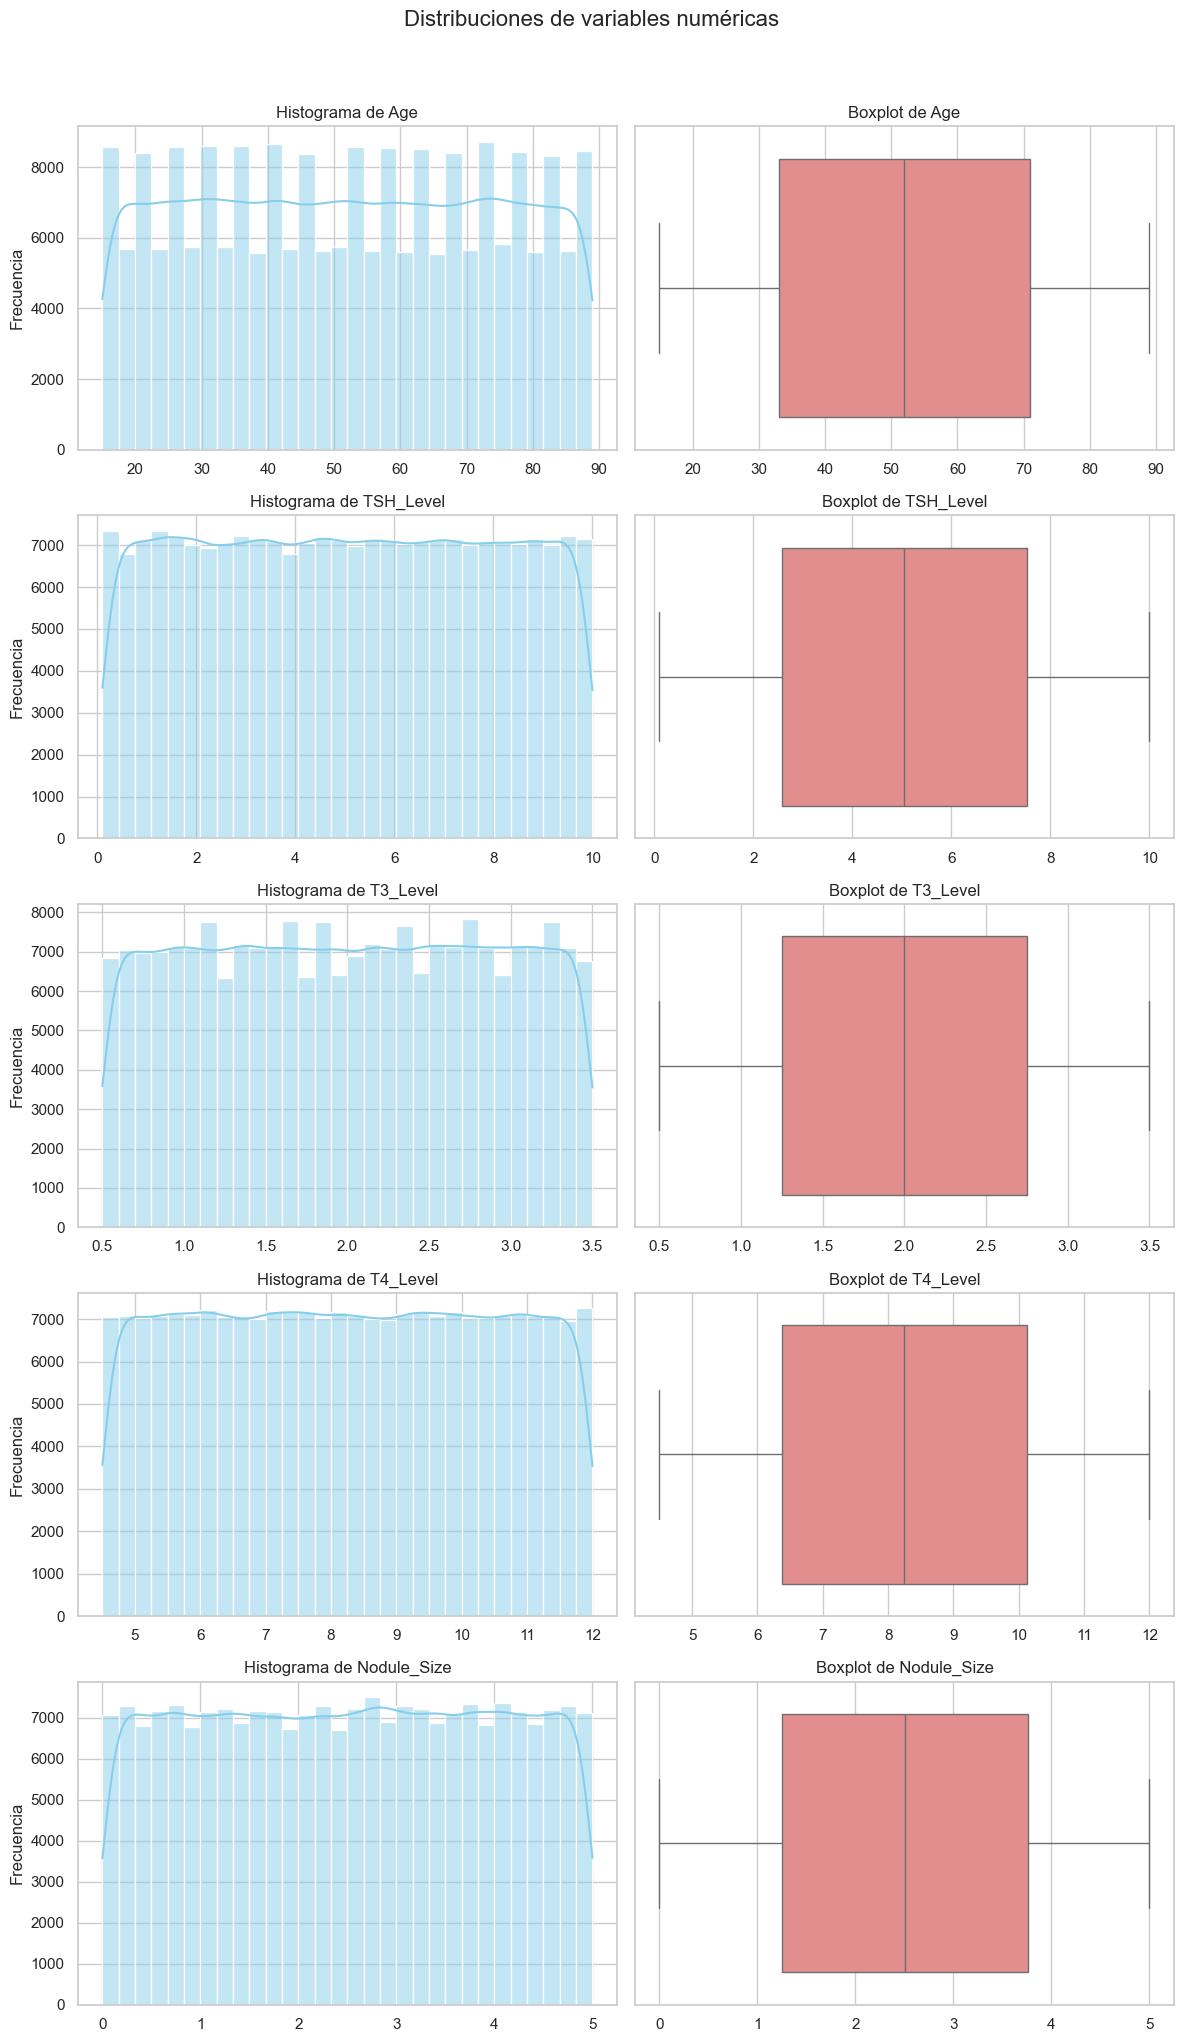

In [21]:
numericas = ['Age', 'TSH_Level', 'T3_Level', 'T4_Level', 'Nodule_Size']
graficar_distribuciones(df,numericas)

se realiza lo mismo para las variables categoricas

In [22]:
categoricas = ['Gender', 'Country', 'Ethnicity', 'Family_History', 'Radiation_Exposure',
               'Iodine_Deficiency', 'Smoking', 'Obesity', 'Diabetes', 'Diagnosis']

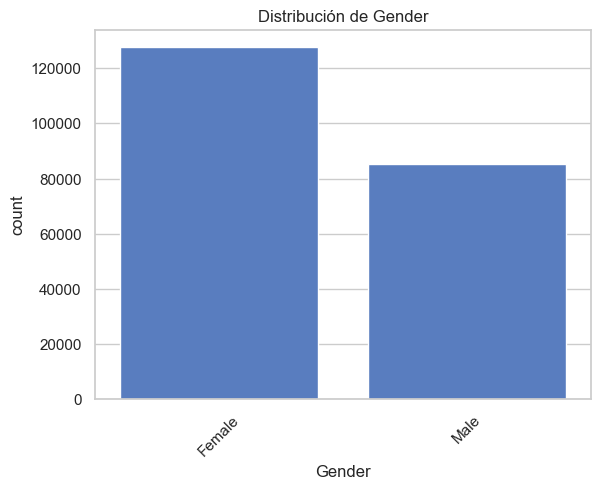

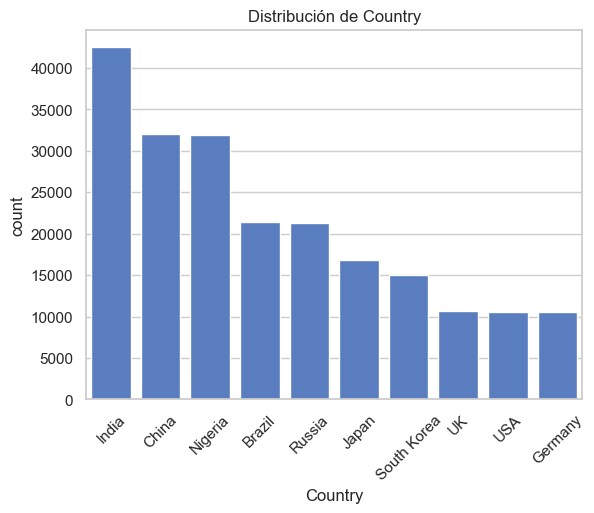

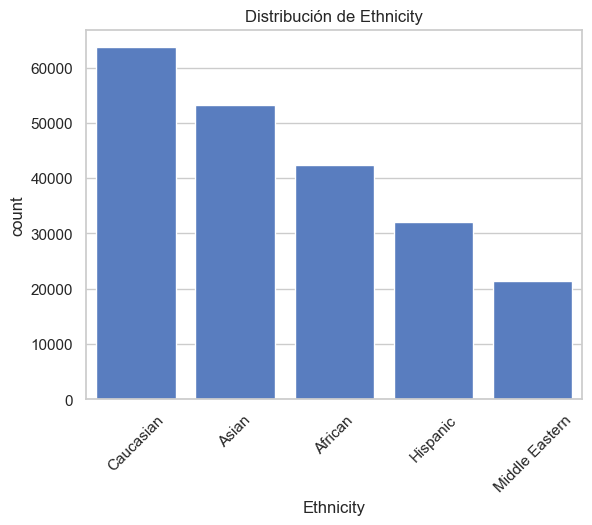

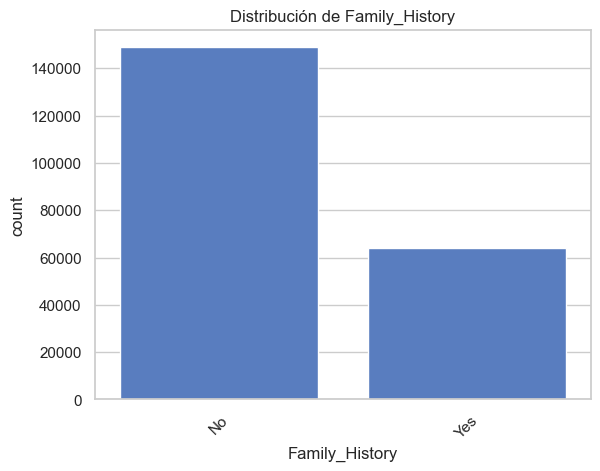

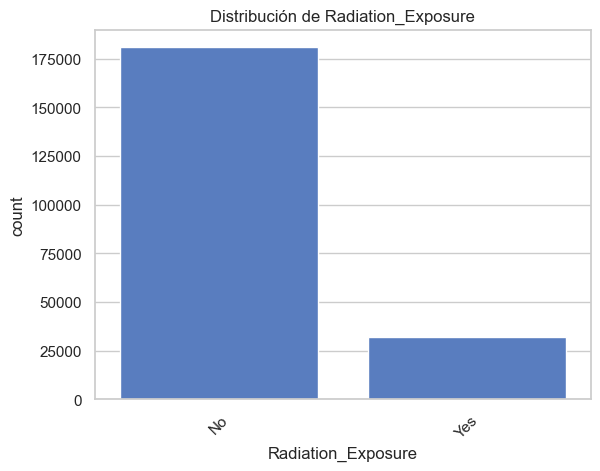

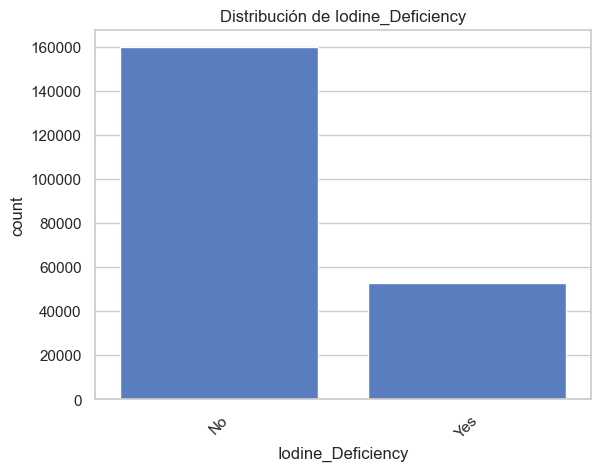

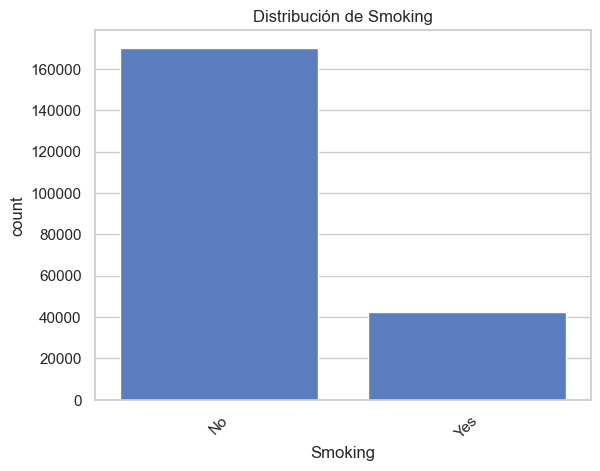

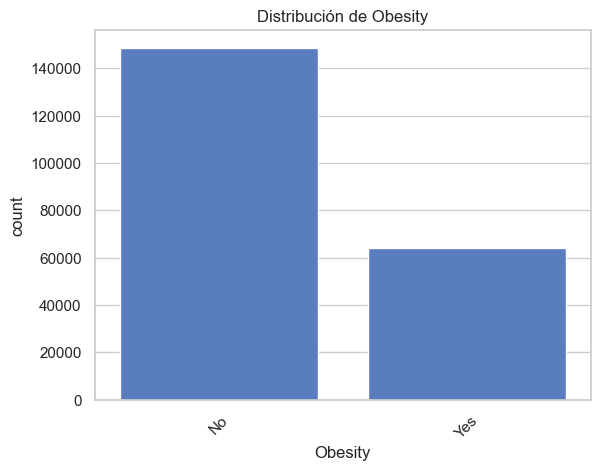

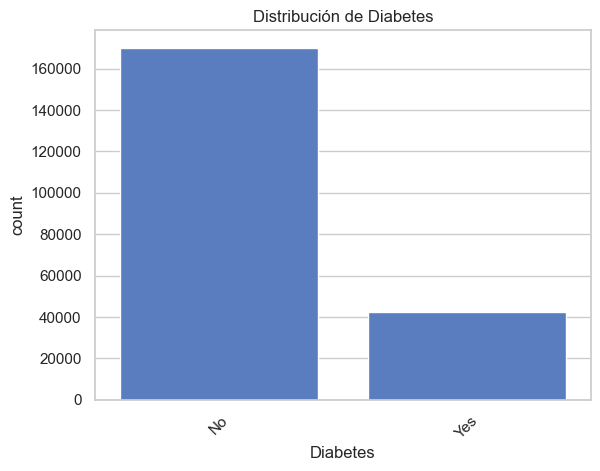

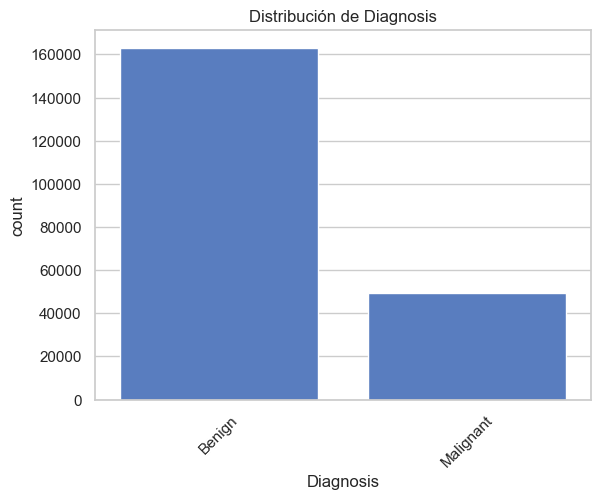

In [23]:
graficar_categoricas(df,categoricas)

## Analisis Bivariado

Realizamos el analisis bivariado de las variables numericas y categoricas 

In [24]:
prueba_normalidad(df)

,variable,n_muestras,shapiro_p,dagostino_p,ks_p,es_normal (alpha=0.05)
0,Age,212691,NaN,0.0,0.0,False
1,TSH_Level,212691,NaN,0.0,0.0,False
2,T3_Level,212691,NaN,0.0,0.0,False
3,T4_Level,212691,NaN,0.0,0.0,False
4,Nodule_Size,212691,NaN,0.0,0.0,False


===  Correlaciones más altas ===


,Variable 1,Variable 2,Correlación Pearson,Correlación Spearman,Covarianza
6,TSH_Level,Nodule_Size,0.000416,0.000423,0.001718
4,TSH_Level,T3_Level,0.000335,0.000335,0.000830
5,TSH_Level,T4_Level,-0.000795,-0.000799,-0.004921
0,Age,TSH_Level,-0.000925,-0.000921,-0.057210
1,Age,T3_Level,-0.001013,-0.001019,-0.018992



=== Correlaciones más bajas ===


,Variable 1,Variable 2,Correlación Pearson,Correlación Spearman,Covarianza
3,Age,Nodule_Size,-0.001489,-0.001485,-0.046526
8,T3_Level,Nodule_Size,-0.001799,-0.001788,-0.002251
9,T4_Level,Nodule_Size,-0.001860,-0.001861,-0.005814
2,Age,T4_Level,-0.002373,-0.002373,-0.111110
7,T3_Level,T4_Level,-0.004069,-0.004063,-0.007629


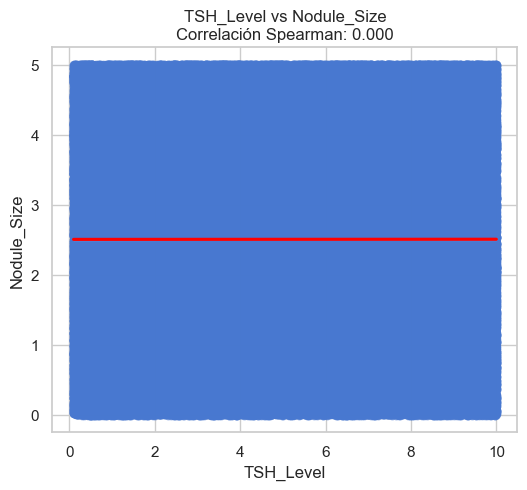

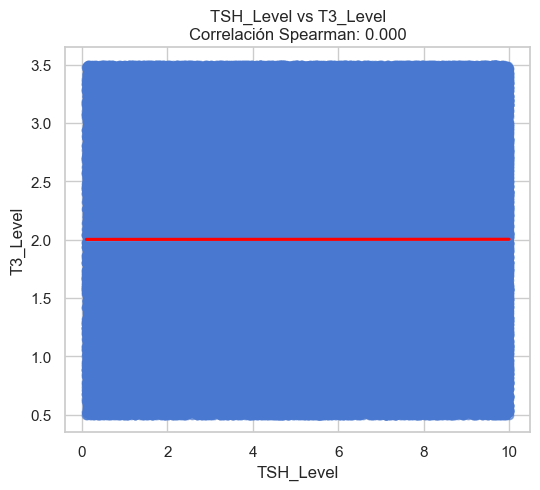

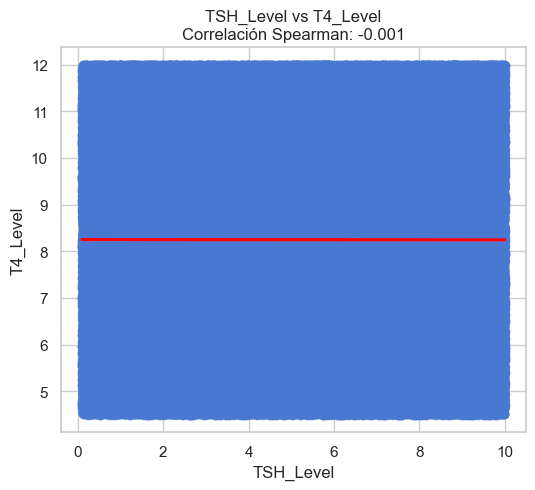

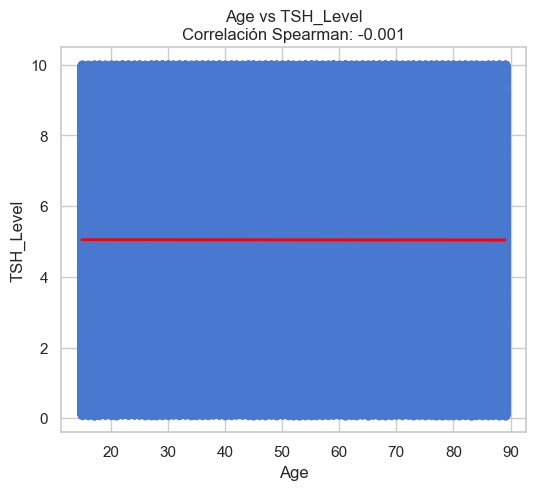

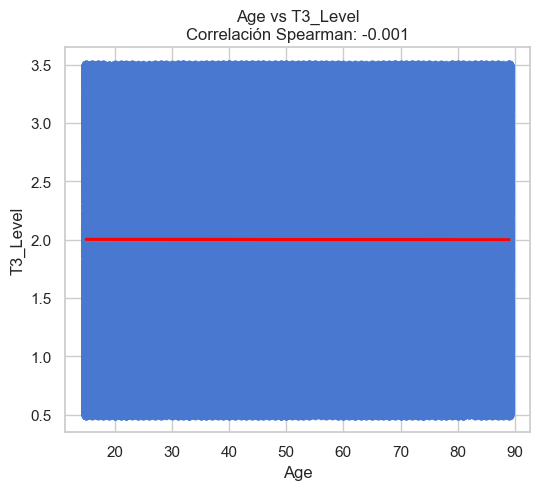

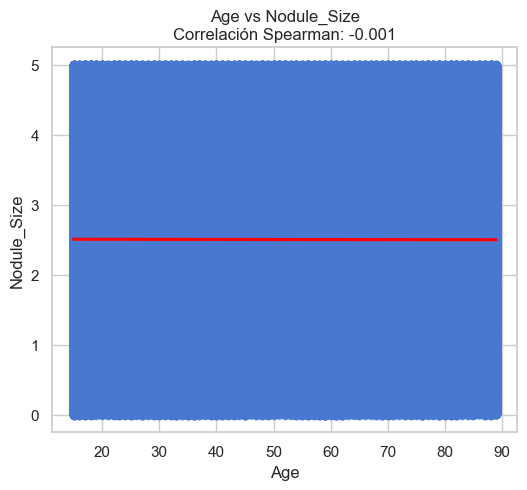

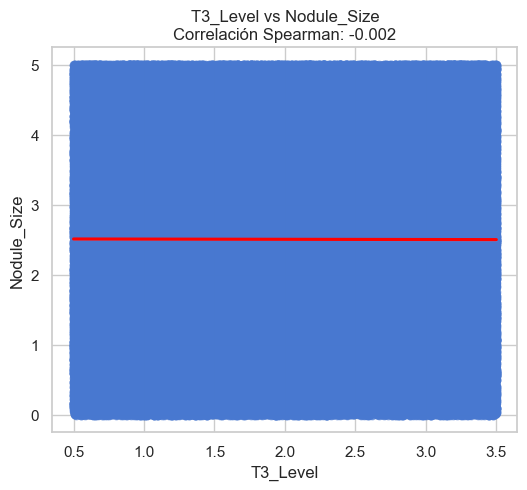

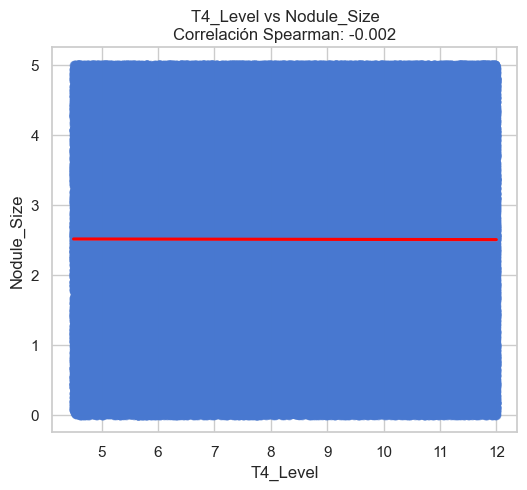

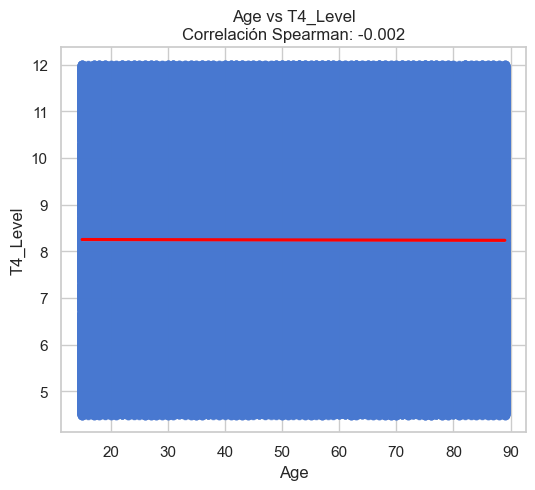

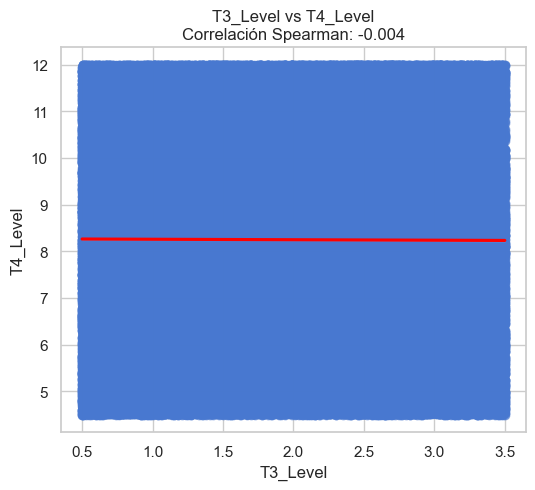

,Variable 1,Variable 2,Correlación Pearson,Correlación Spearman,Covarianza
6,TSH_Level,Nodule_Size,0.000416,0.000423,0.001718
4,TSH_Level,T3_Level,0.000335,0.000335,0.000830
5,TSH_Level,T4_Level,-0.000795,-0.000799,-0.004921
0,Age,TSH_Level,-0.000925,-0.000921,-0.057210
1,Age,T3_Level,-0.001013,-0.001019,-0.018992
3,Age,Nodule_Size,-0.001489,-0.001485,-0.046526
8,T3_Level,Nodule_Size,-0.001799,-0.001788,-0.002251
9,T4_Level,Nodule_Size,-0.001860,-0.001861,-0.005814
2,Age,T4_Level,-0.002373,-0.002373,-0.111110
7,T3_Level,T4_Level,-0.004069,-0.004063,-0.007629


In [25]:
analisis_bivariado_numerico(df,top=5,mostrar_graficos=True)

=== Relaciones categóricas más significativas (menor valor p) ===


,Variable 1,Variable 2,Chi-cuadrado,Grados de libertad,Valor p,V de Cramer
0,Ethnicity,Thyroid_Cancer_Risk,24048.658999,8,0.0,0.237731
1,Ethnicity,Diagnosis,5146.683841,4,0.0,0.155497
2,Country,Diagnosis,2757.420910,9,0.0,0.113676
3,Country,Thyroid_Cancer_Risk,13307.120917,18,0.0,0.176750
4,Radiation_Exposure,Diagnosis,1685.753639,1,0.0,0.089001



=== Relaciones menos significativas ===


,Variable 1,Variable 2,Chi-cuadrado,Grados de libertad,Valor p,V de Cramer
50,Family_History,Diabetes,0.035534,1,0.850480,0.0
51,Family_History,Smoking,0.032947,1,0.855966,0.0
52,Radiation_Exposure,Diabetes,0.004245,1,0.948053,0.0
53,Smoking,Diabetes,0.003945,1,0.949920,0.0
54,Country,Obesity,2.996919,9,0.964417,0.0



Gráficos de las relaciones más significativas:

Ethnicity vs Thyroid_Cancer_Risk (p = 0.0000, V de Cramer = 0.238)


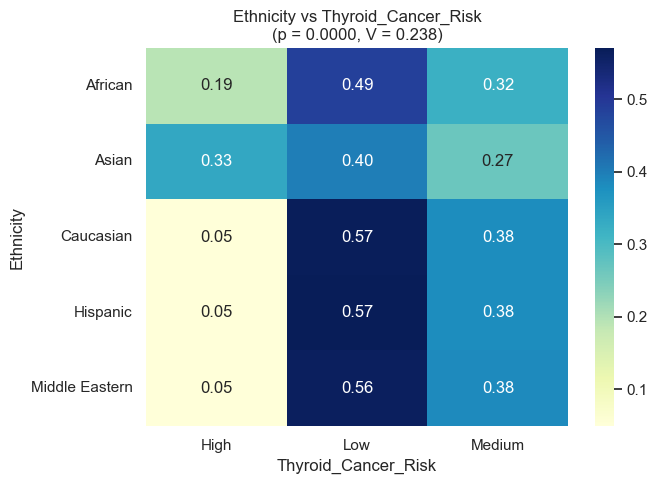


Ethnicity vs Diagnosis (p = 0.0000, V de Cramer = 0.155)


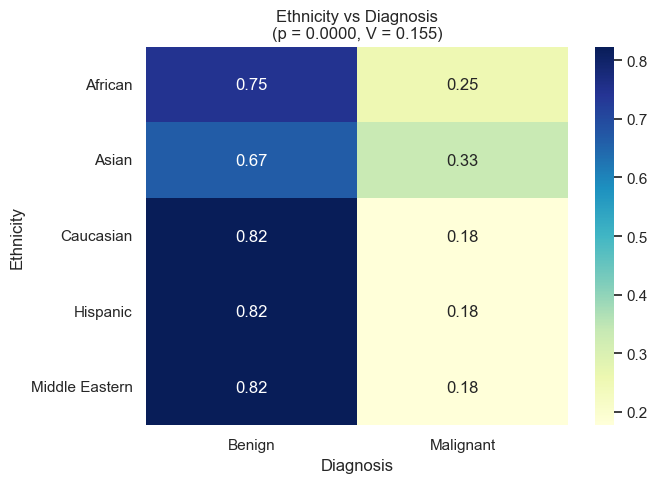


Country vs Diagnosis (p = 0.0000, V de Cramer = 0.114)


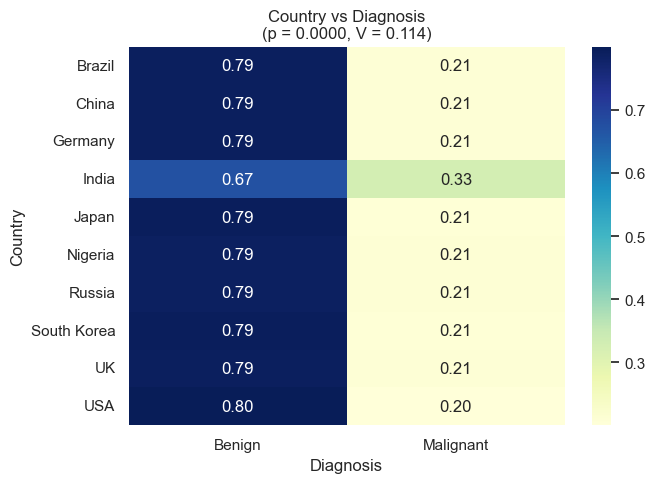


Country vs Thyroid_Cancer_Risk (p = 0.0000, V de Cramer = 0.177)


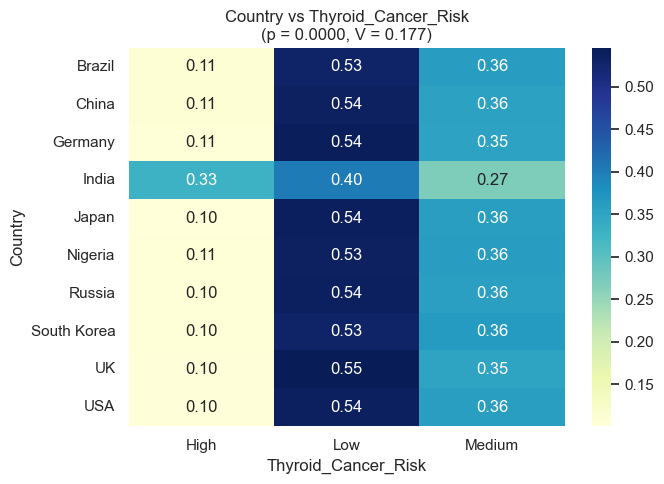


Radiation_Exposure vs Diagnosis (p = 0.0000, V de Cramer = 0.089)


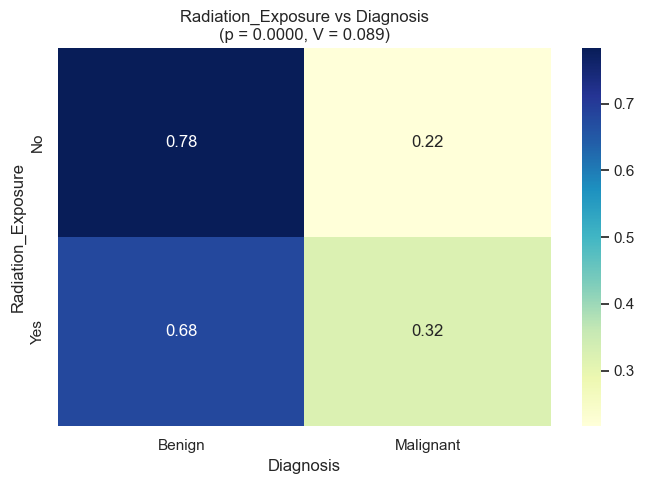

,Variable 1,Variable 2,Chi-cuadrado,Grados de libertad,Valor p,V de Cramer
0,Ethnicity,Thyroid_Cancer_Risk,24048.658999,8,0.000000,0.237731
1,Ethnicity,Diagnosis,5146.683841,4,0.000000,0.155497
2,Country,Diagnosis,2757.420910,9,0.000000,0.113676
3,Country,Thyroid_Cancer_Risk,13307.120917,18,0.000000,0.176750
4,Radiation_Exposure,Diagnosis,1685.753639,1,0.000000,0.089001
5,Radiation_Exposure,Thyroid_Cancer_Risk,7505.195052,2,0.000000,0.187823
6,Family_History,Diagnosis,4223.059166,1,0.000000,0.140893
7,Family_History,Thyroid_Cancer_Risk,19926.918897,2,0.000000,0.306073
8,Iodine_Deficiency,Thyroid_Cancer_Risk,9946.122124,2,0.000000,0.216227
9,Thyroid_Cancer_Risk,Diagnosis,45942.931977,2,0.000000,0.464757


In [26]:
analisis_bivariado_categorico(df,top=5,mostrar_graficos=True)

In [27]:
categoricas.append('Thyroid_Cancer_Risk')

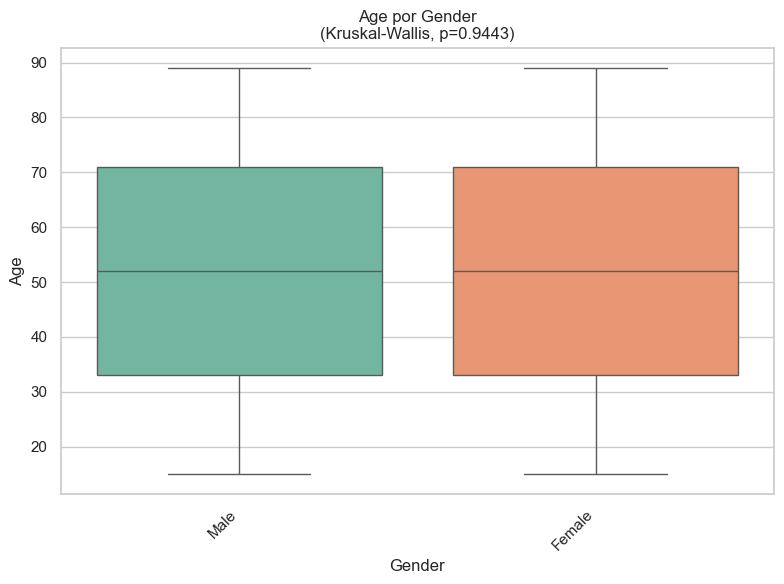

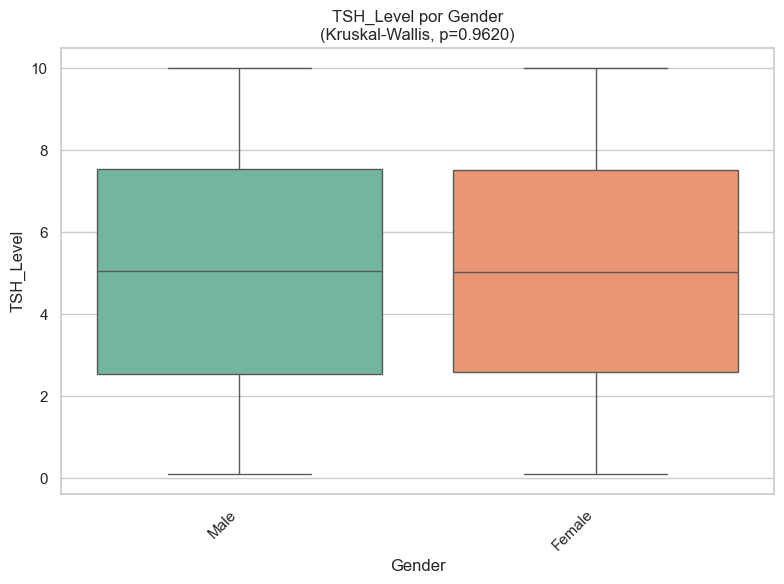

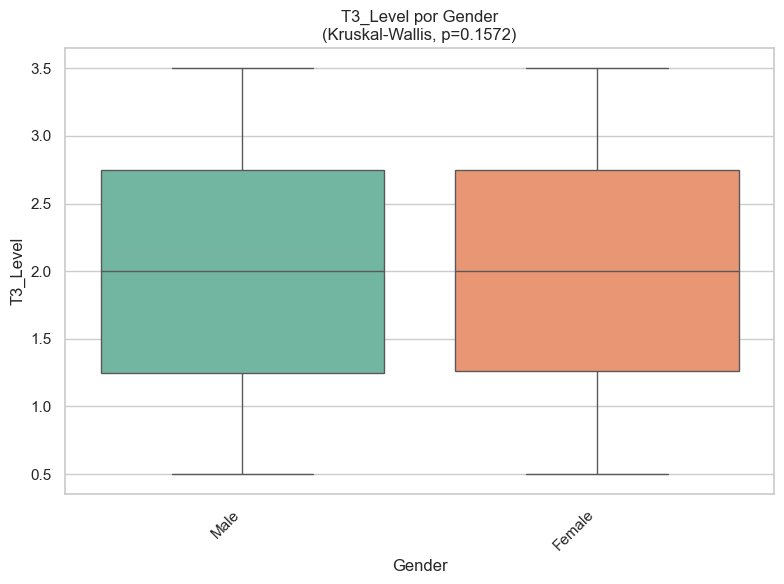

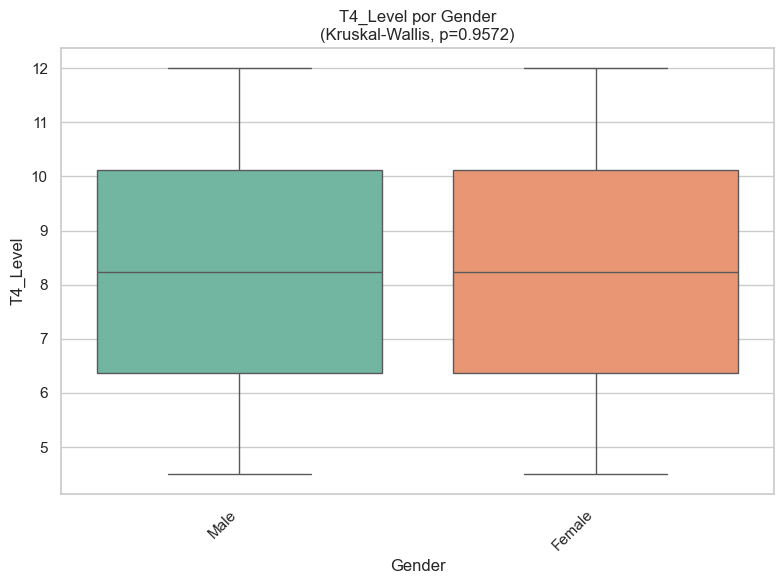

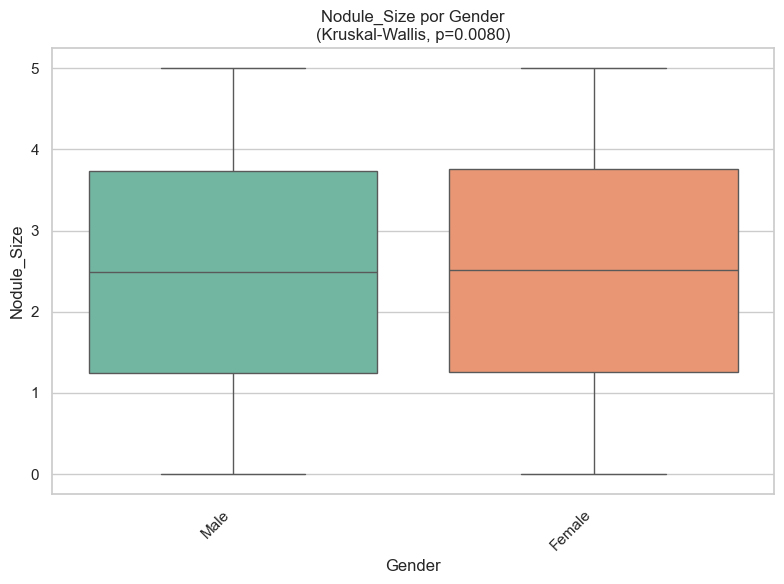

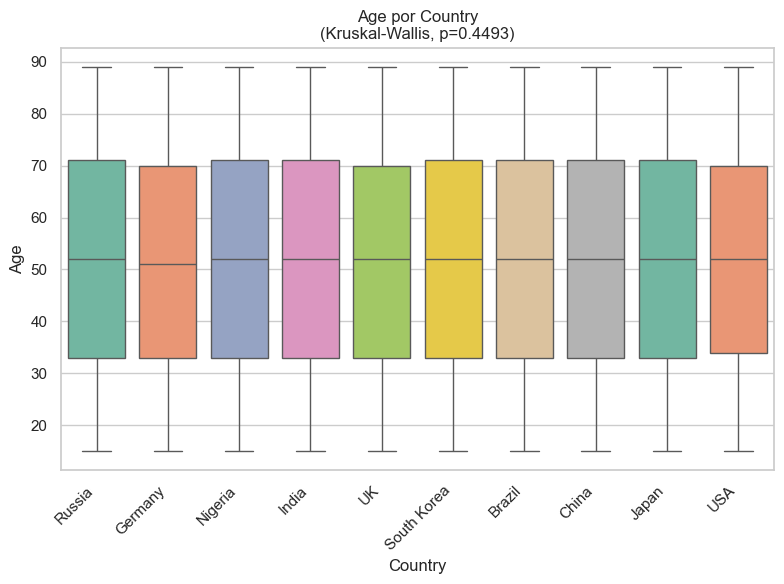

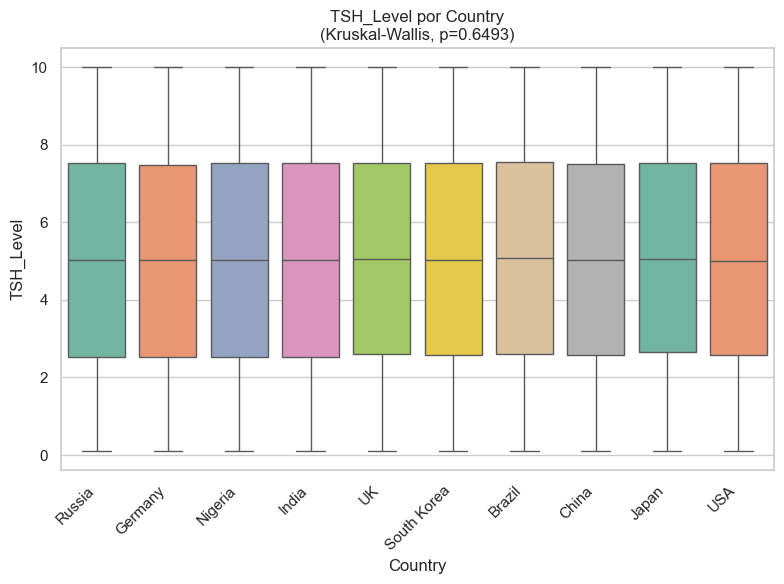

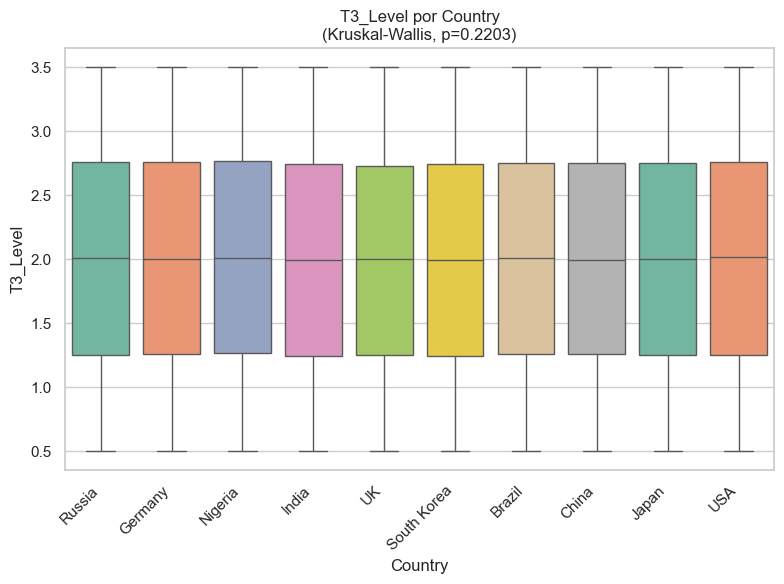

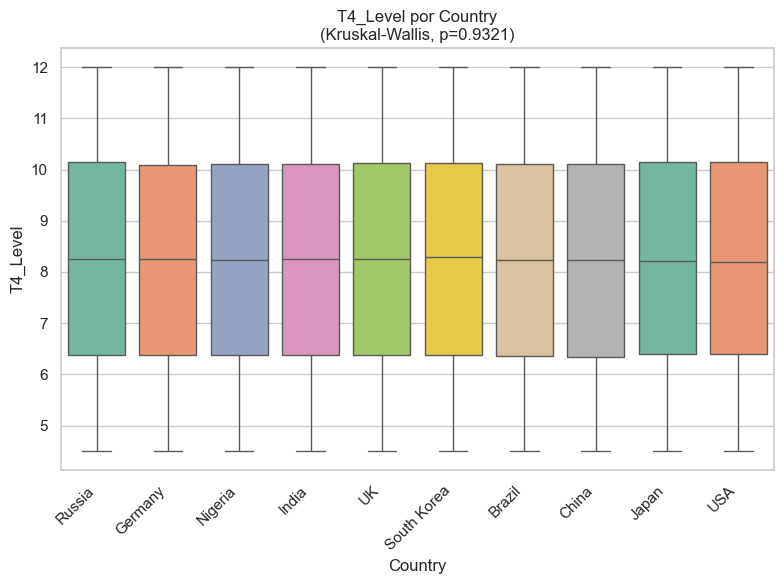

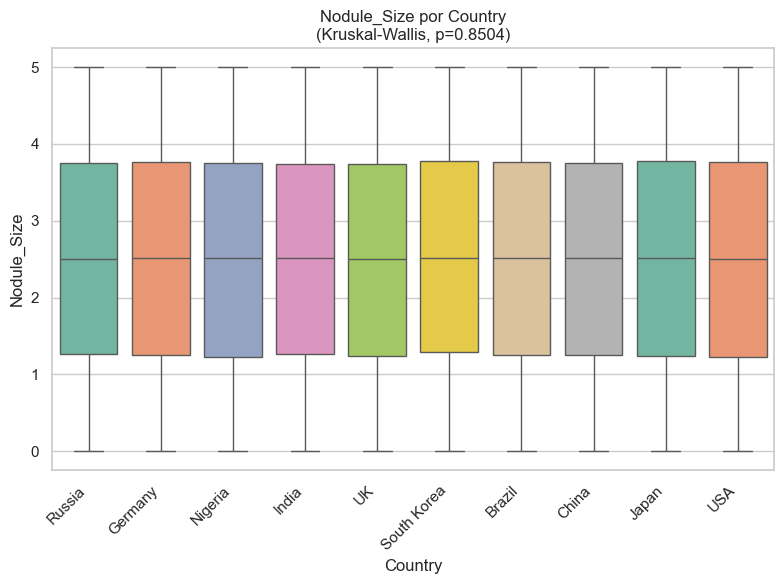

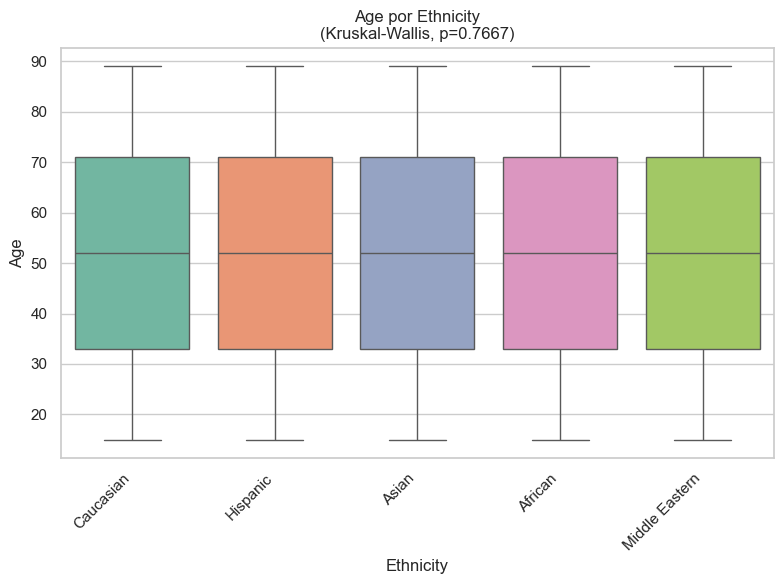

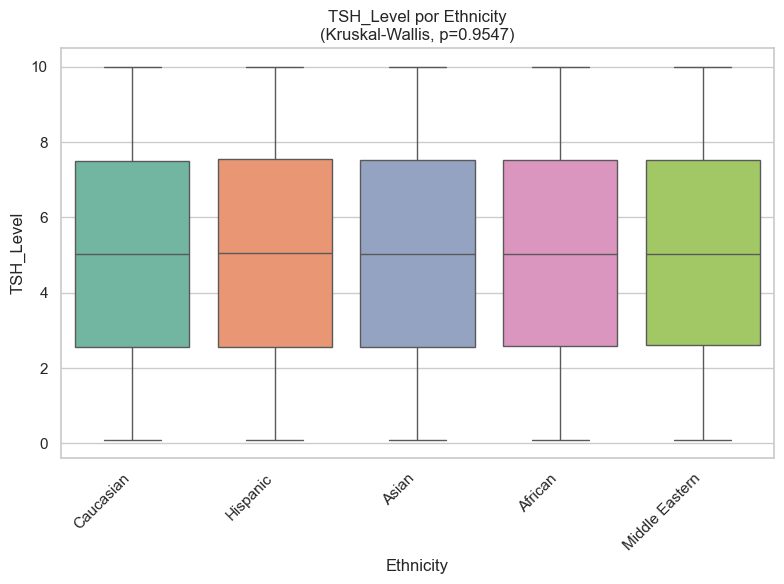

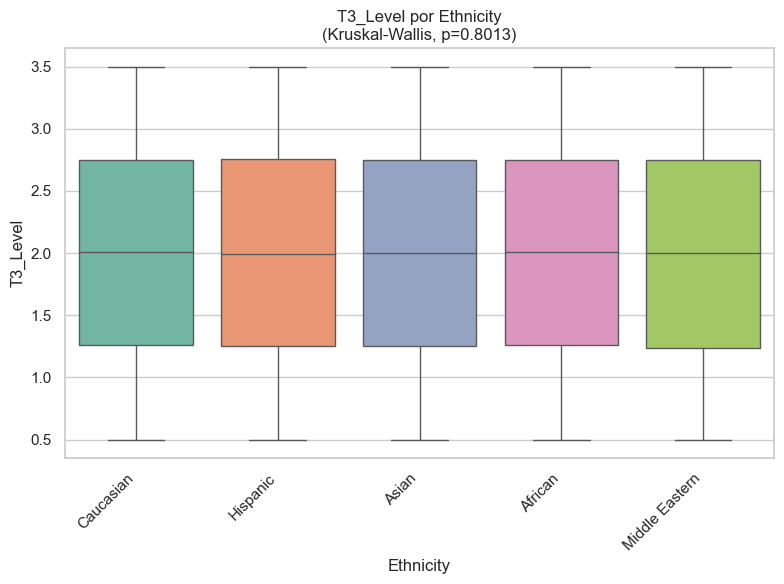

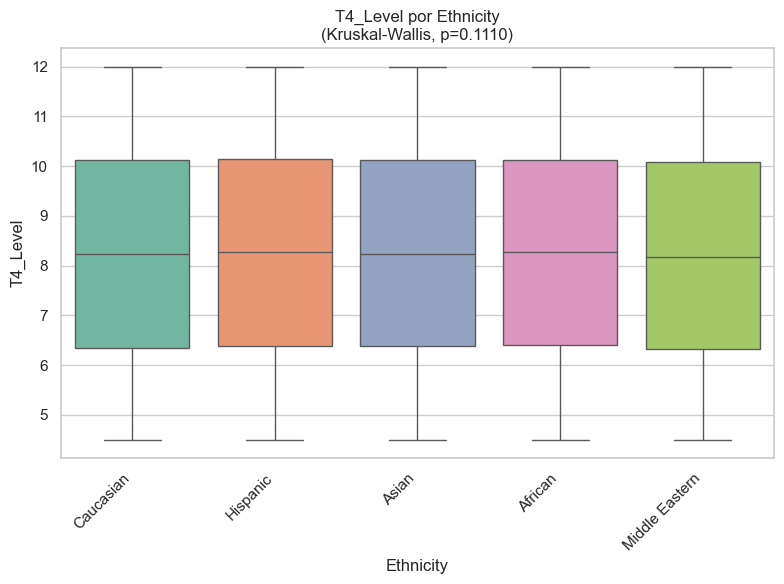

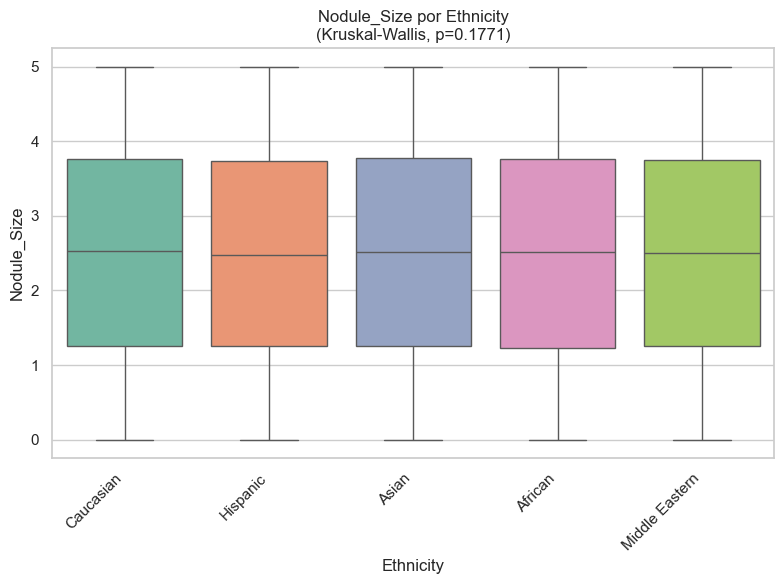

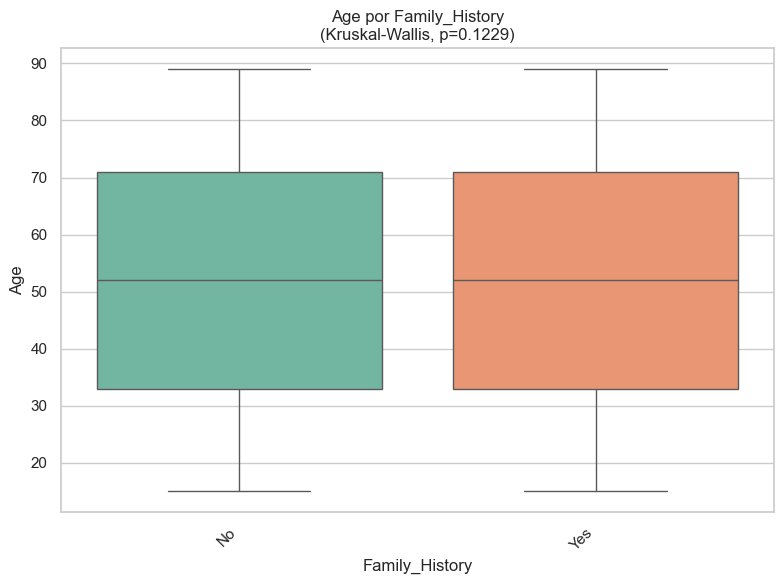

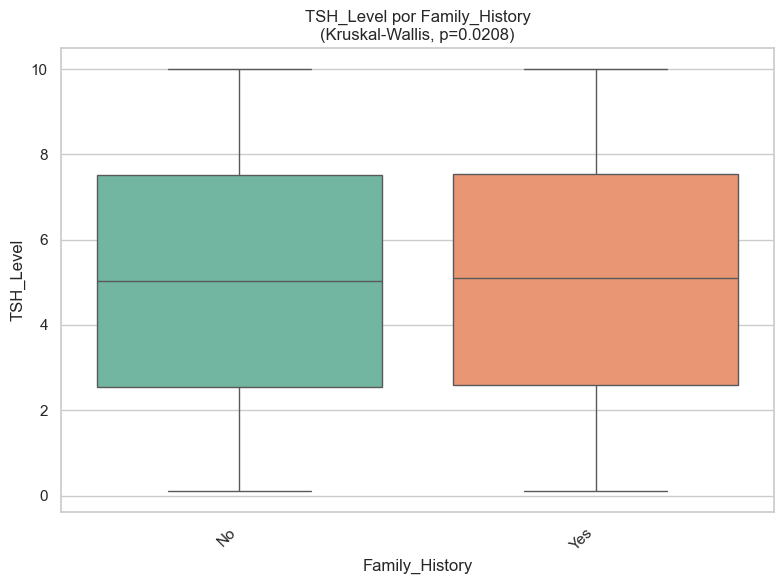

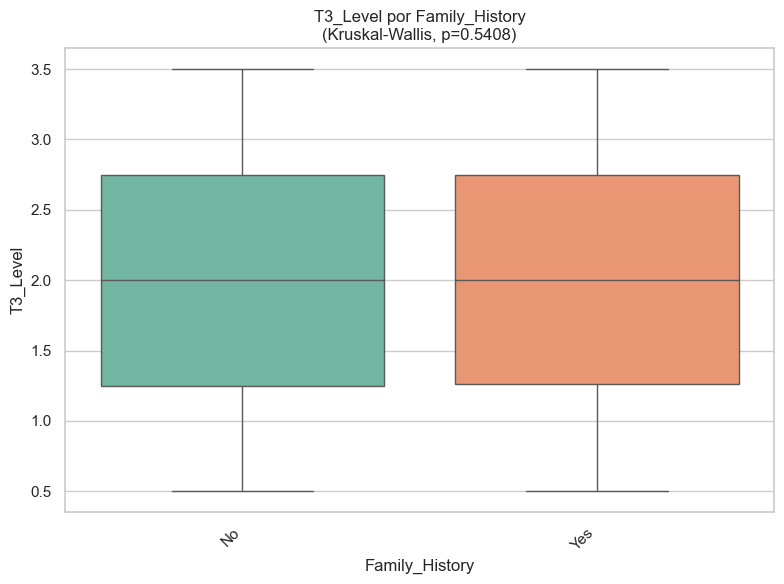

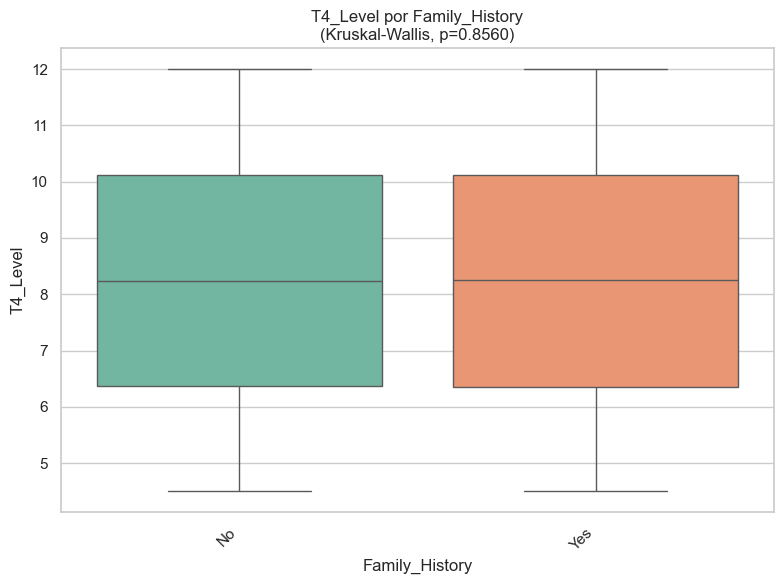

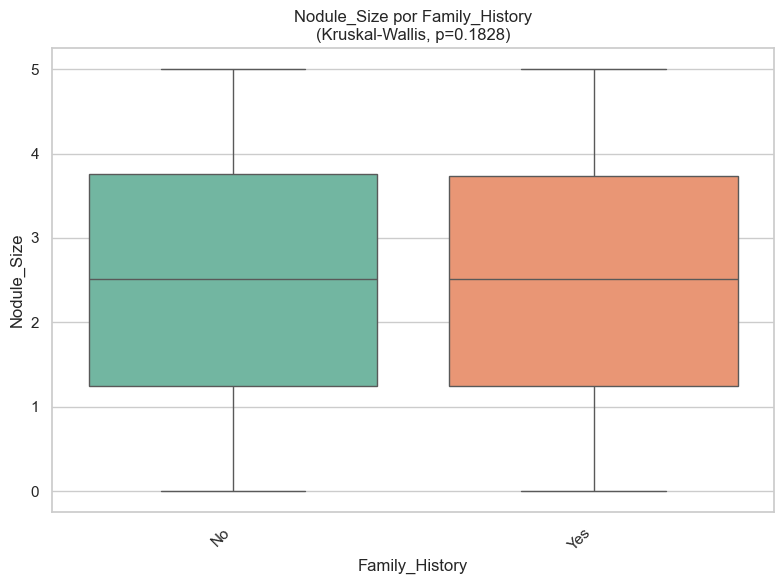

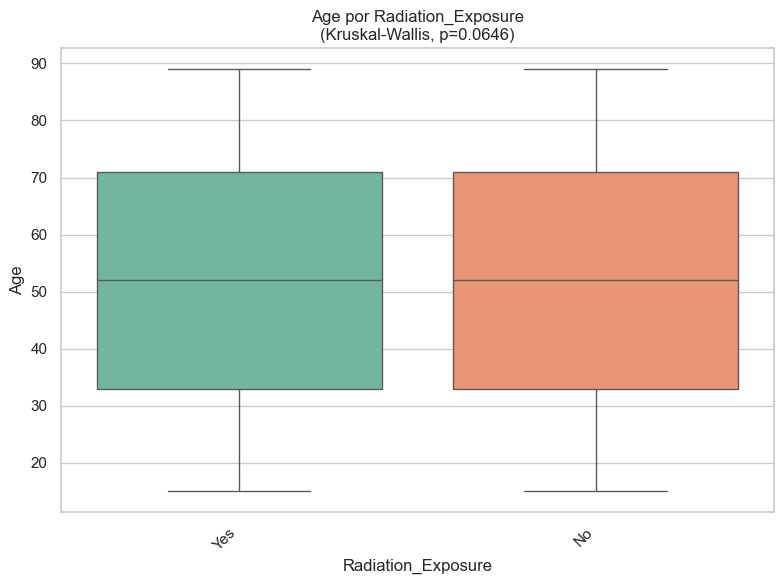

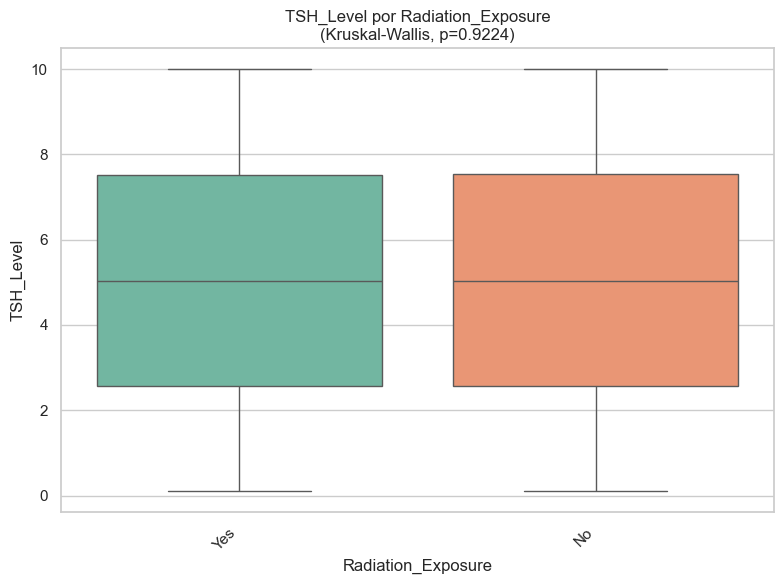

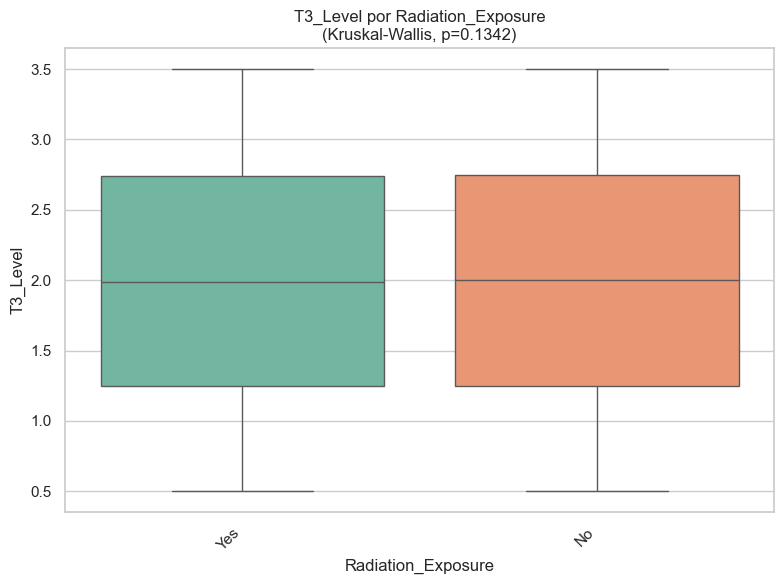

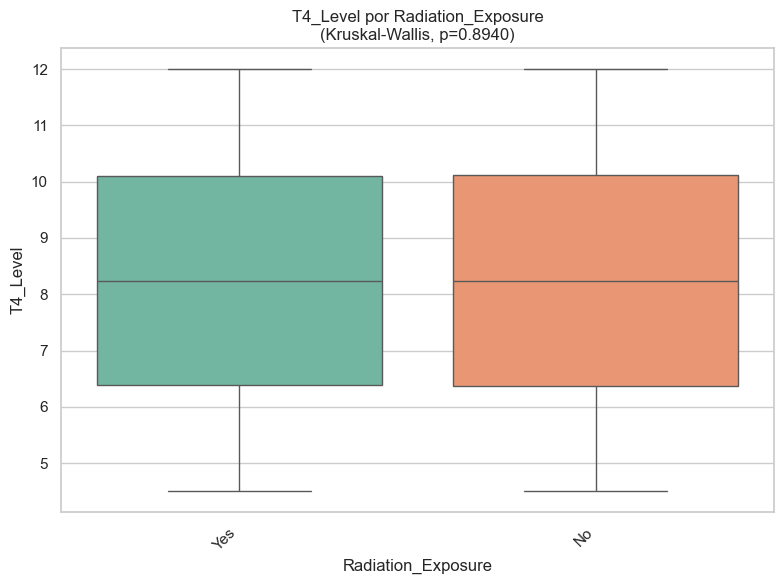

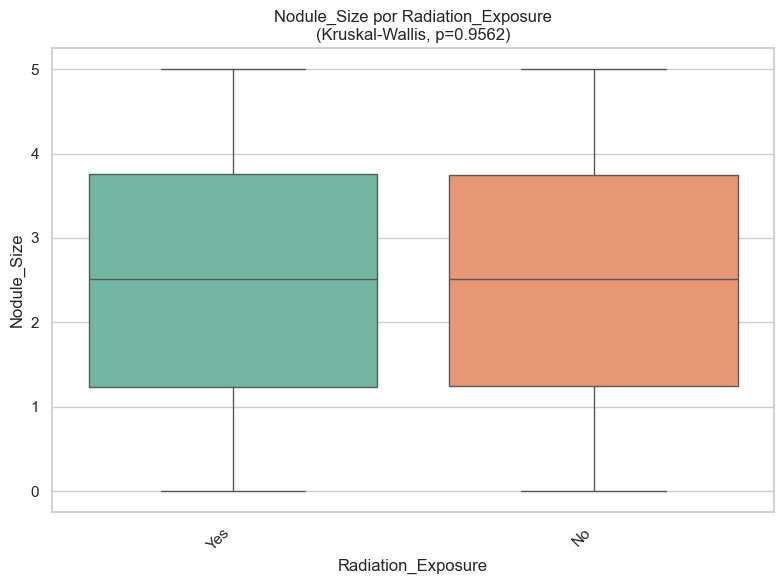

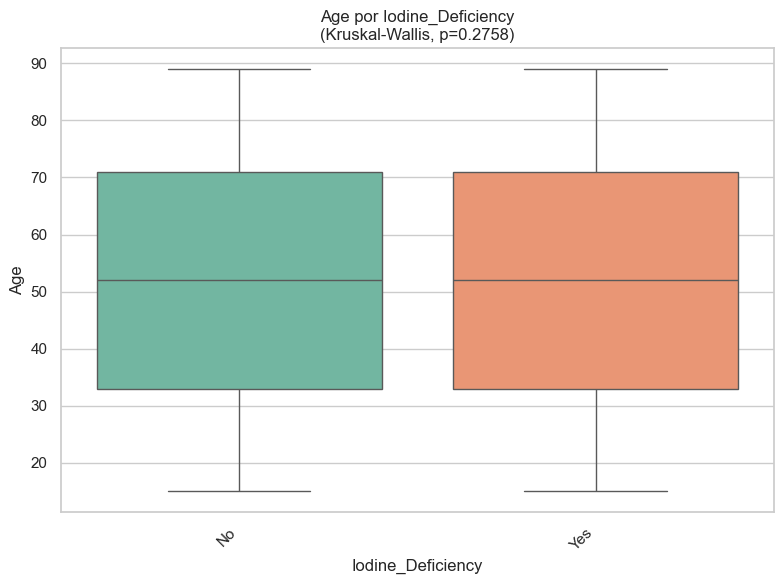

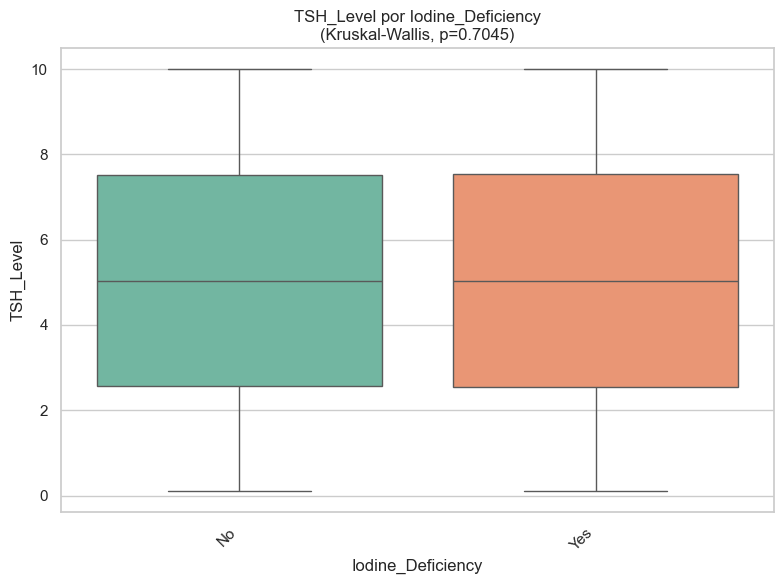

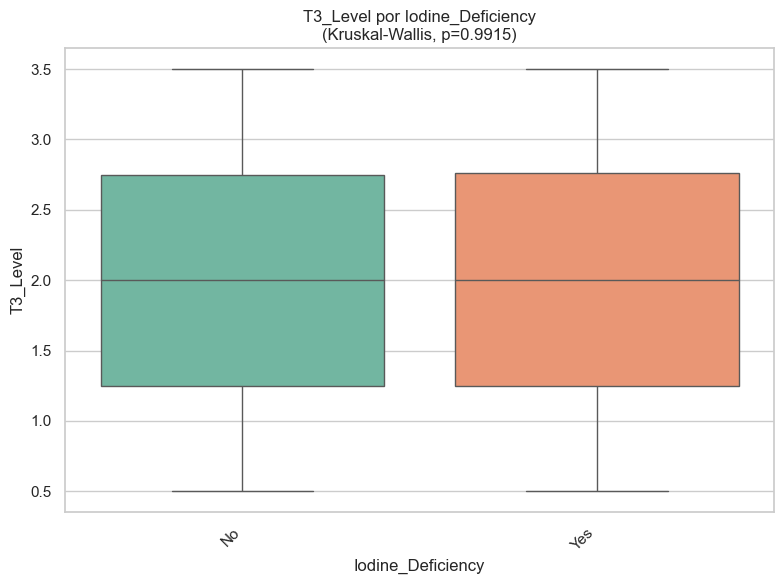

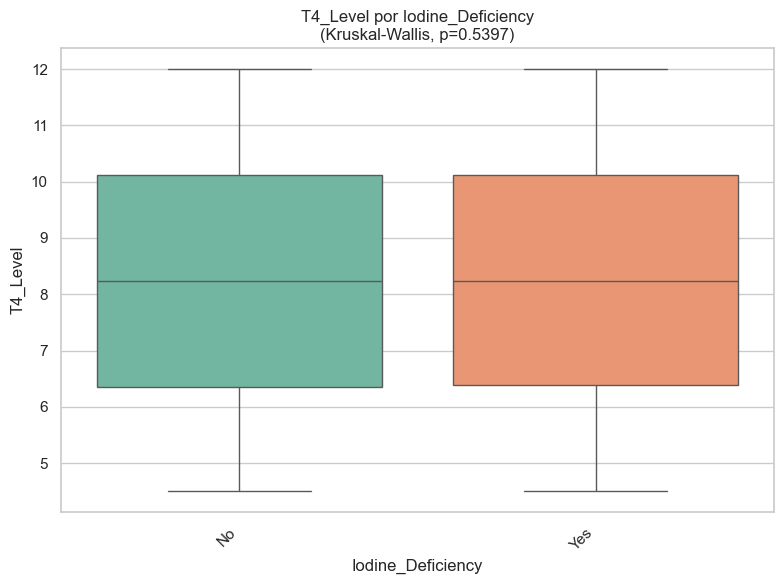

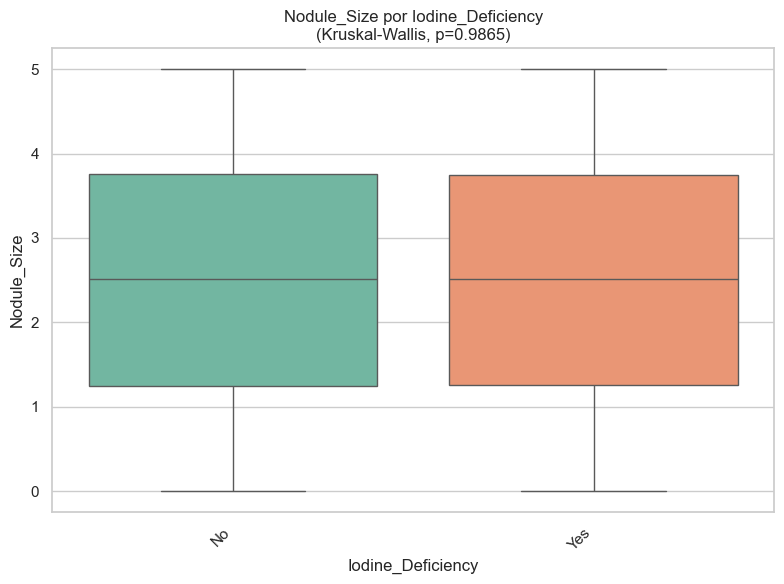

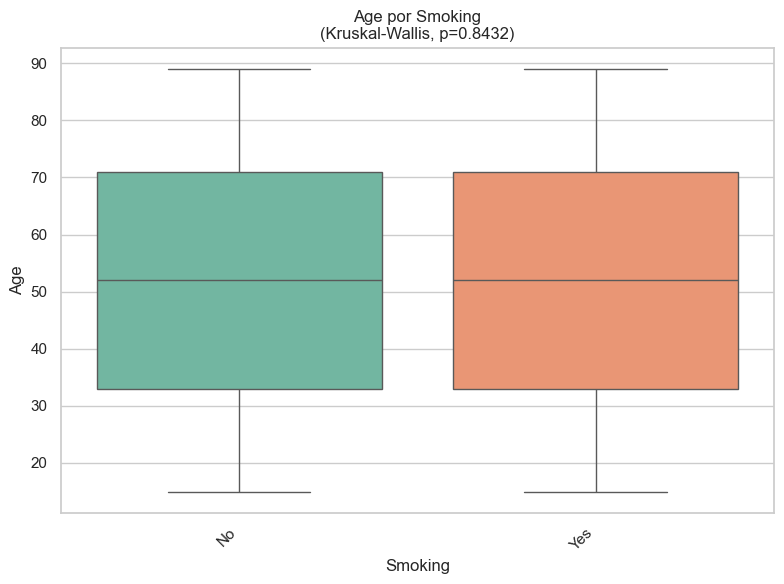

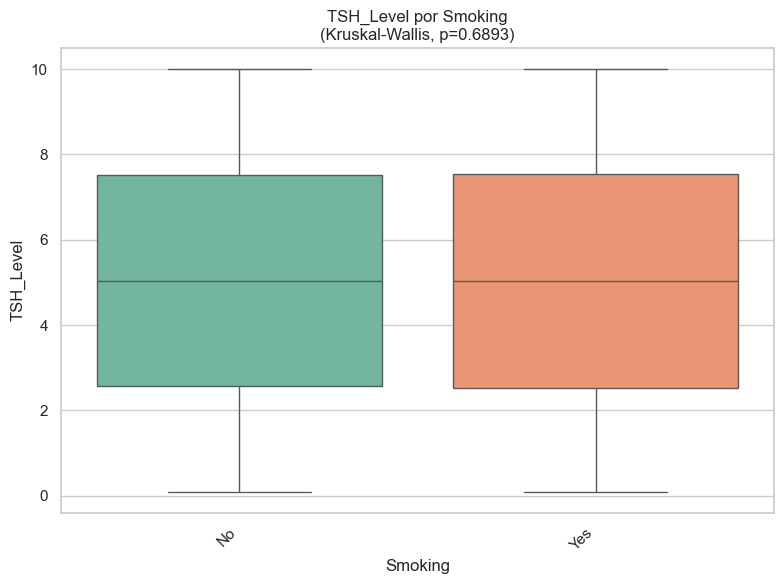

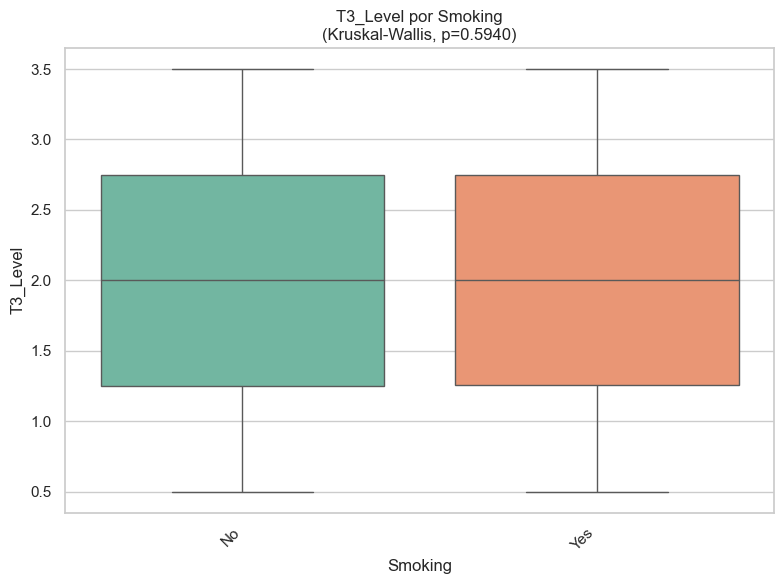

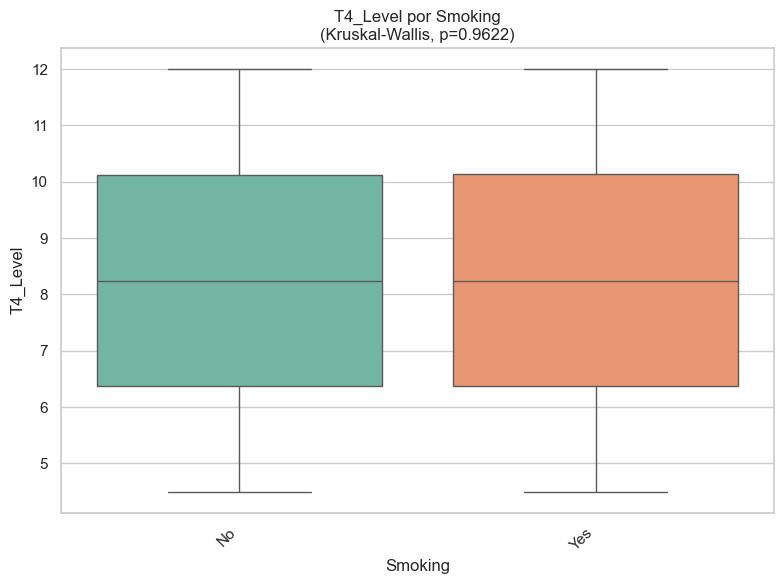

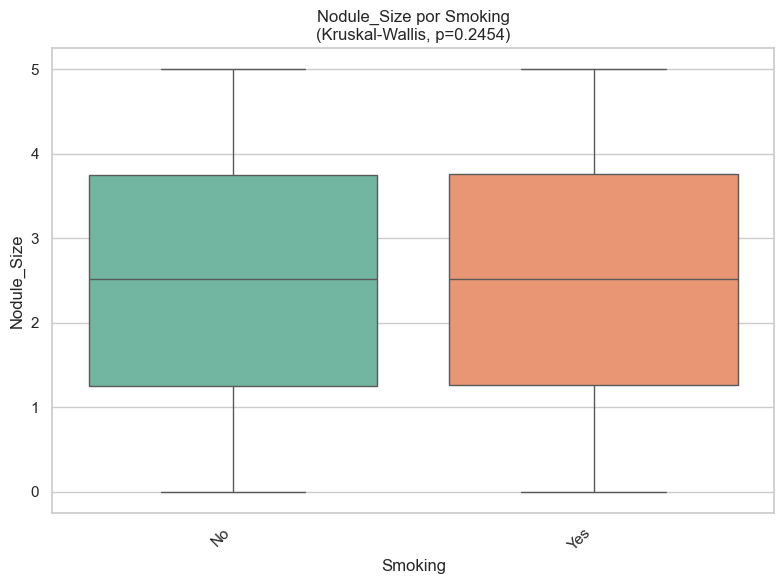

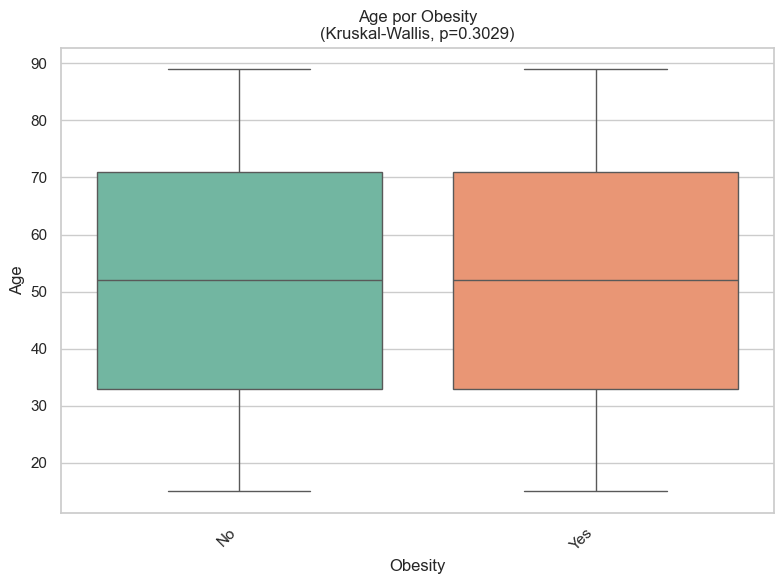

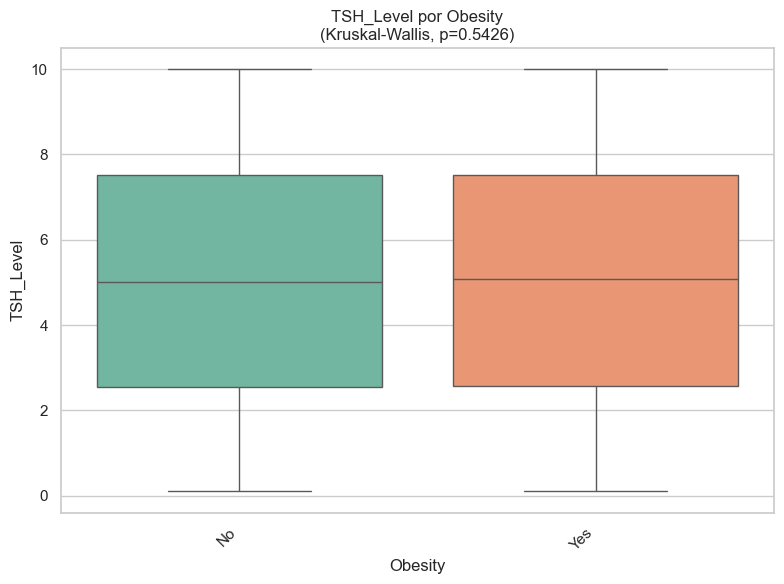

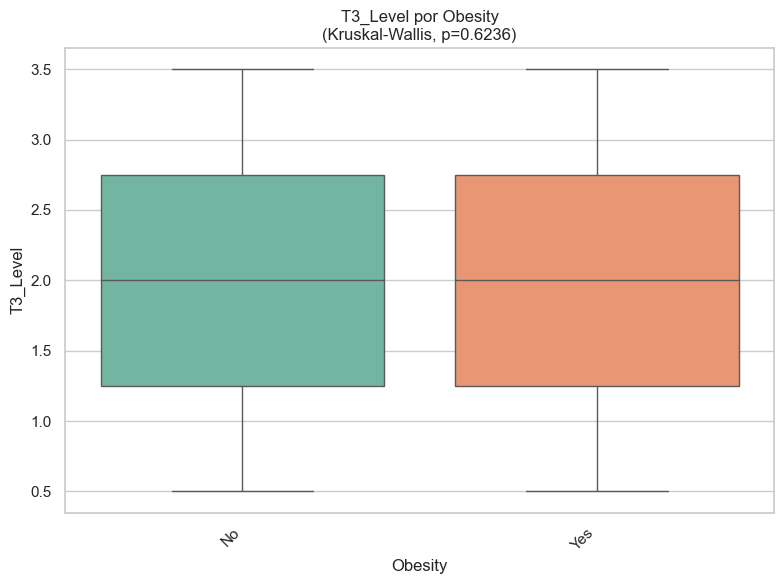

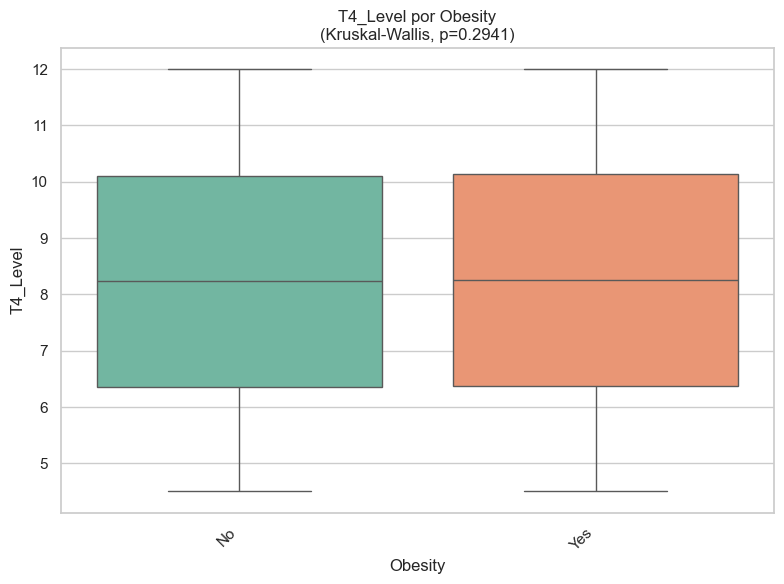

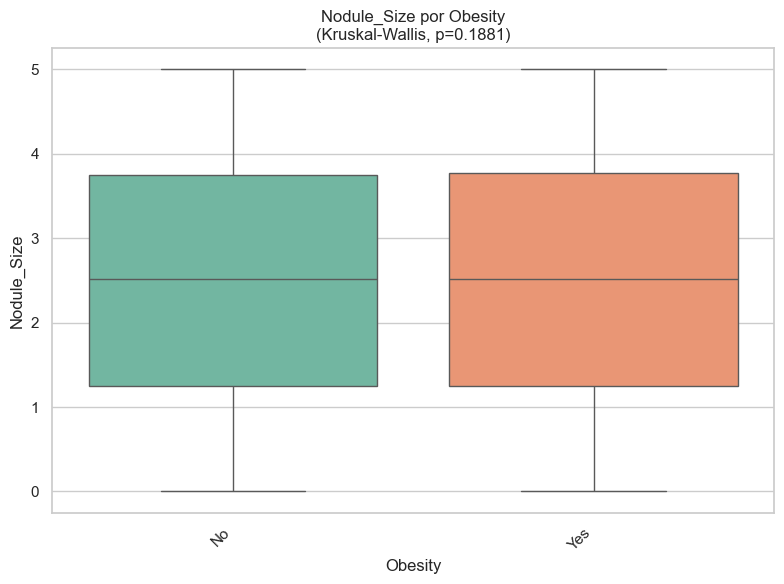

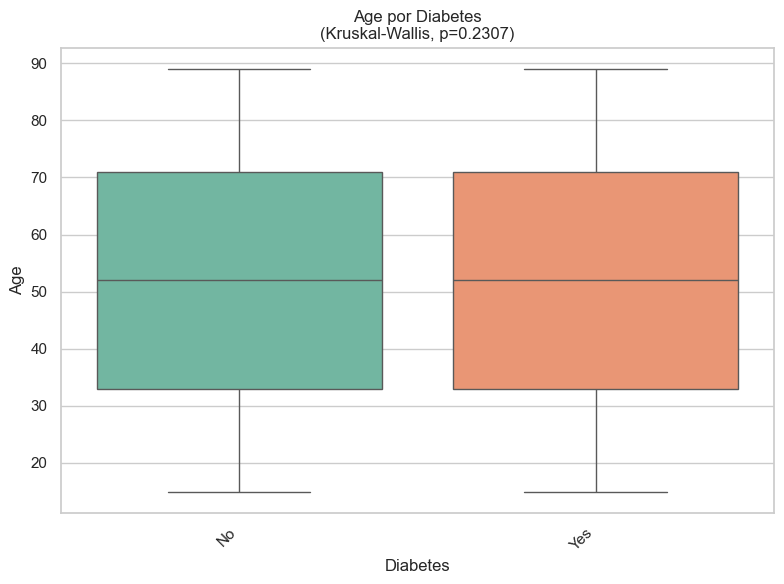

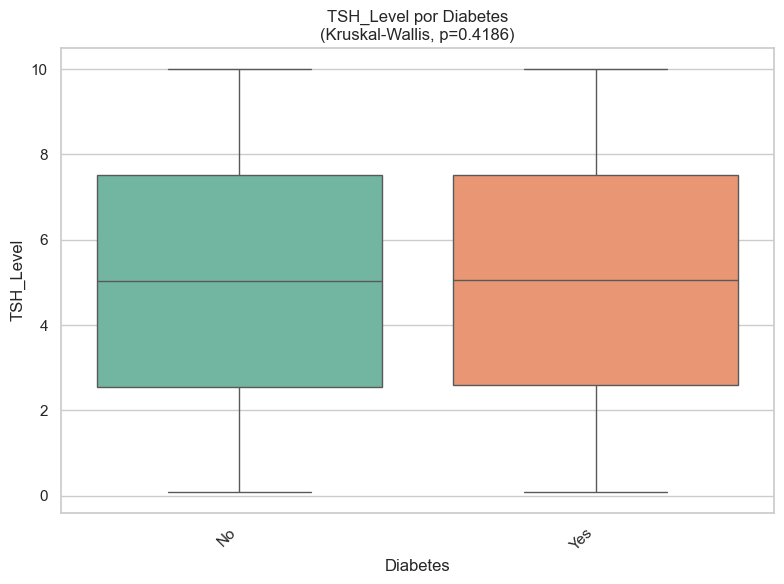

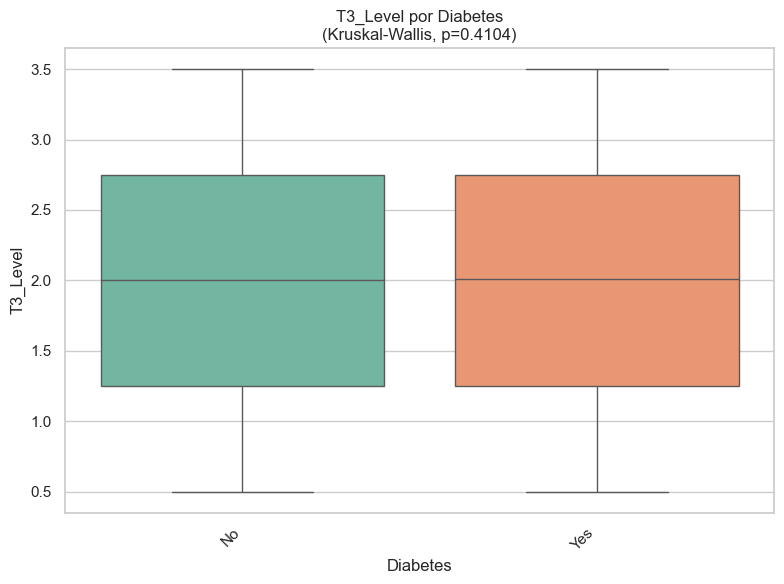

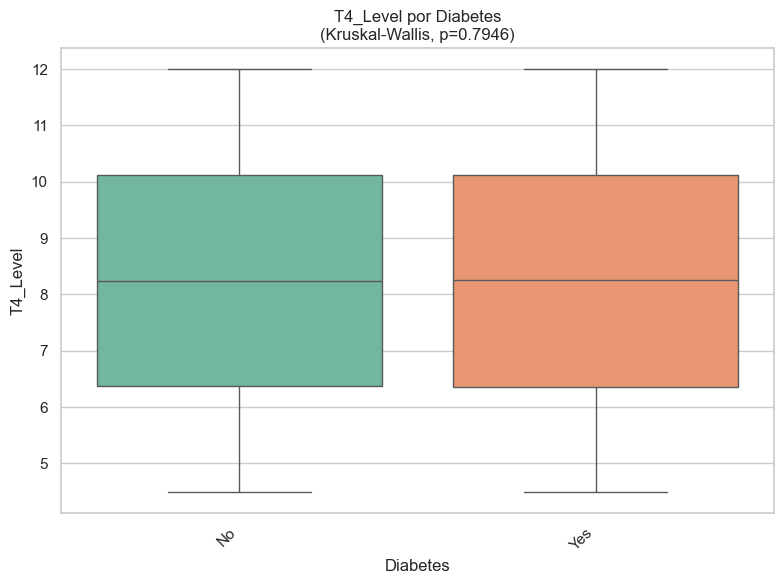

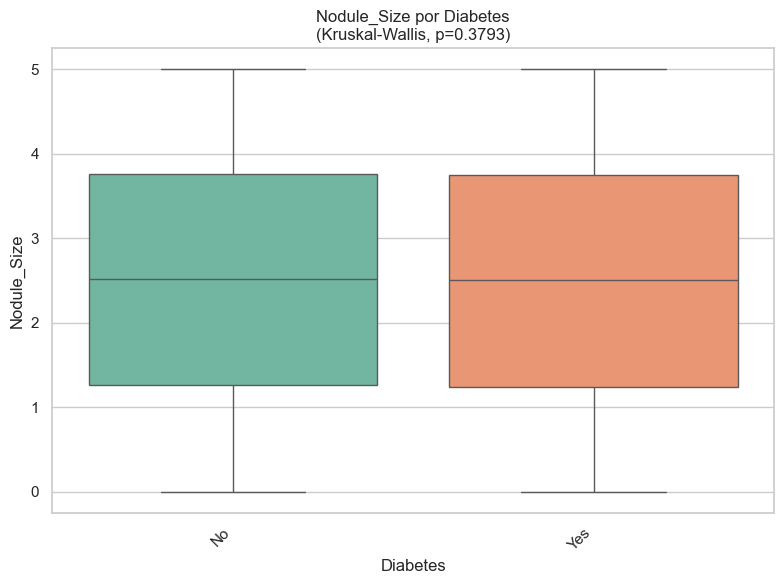

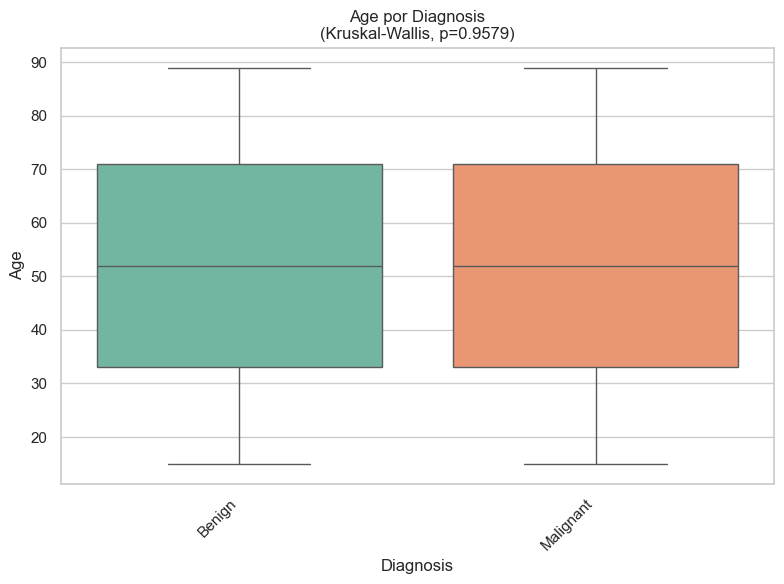

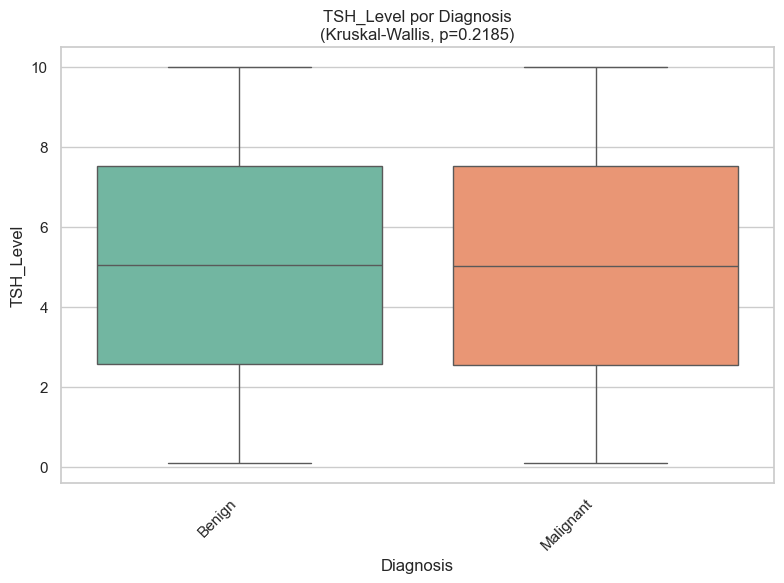

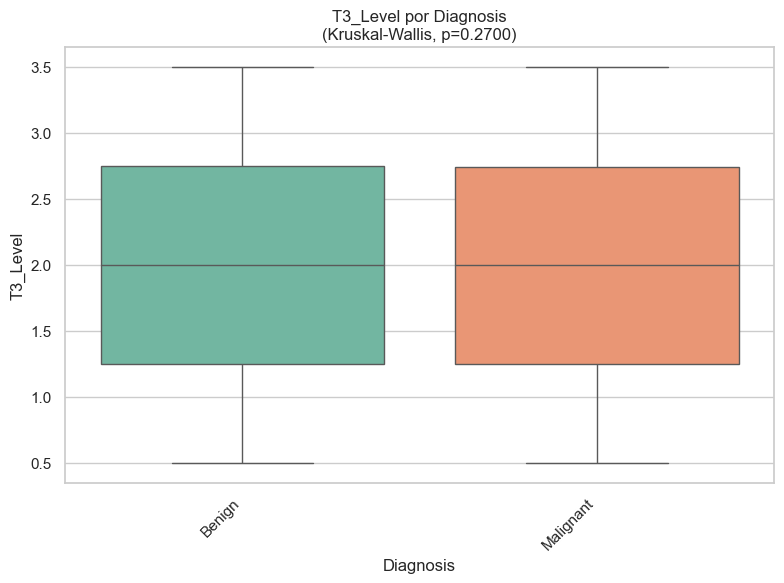

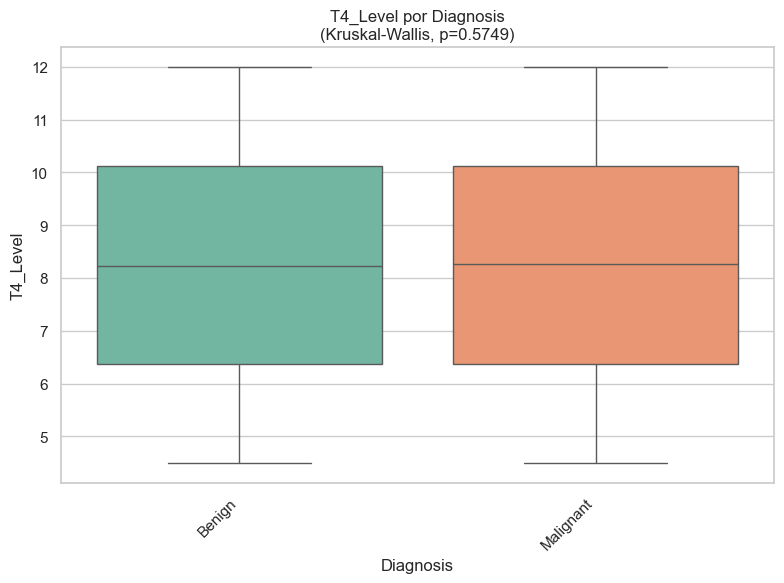

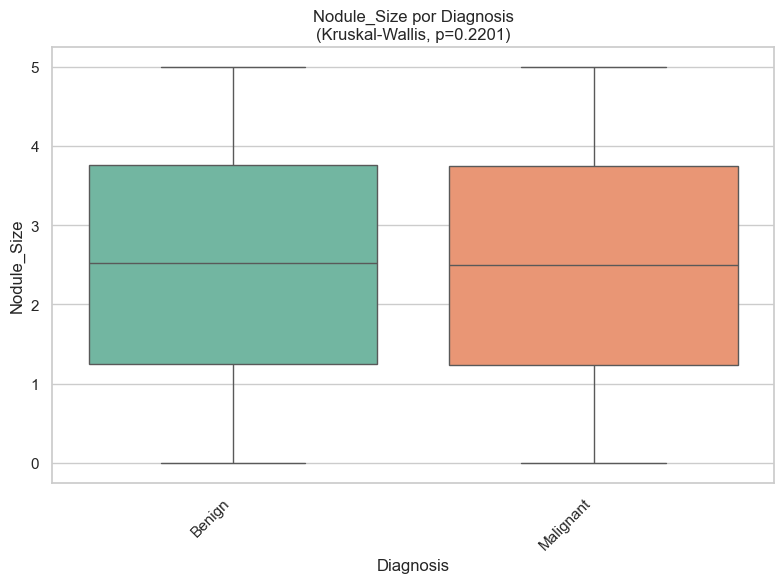

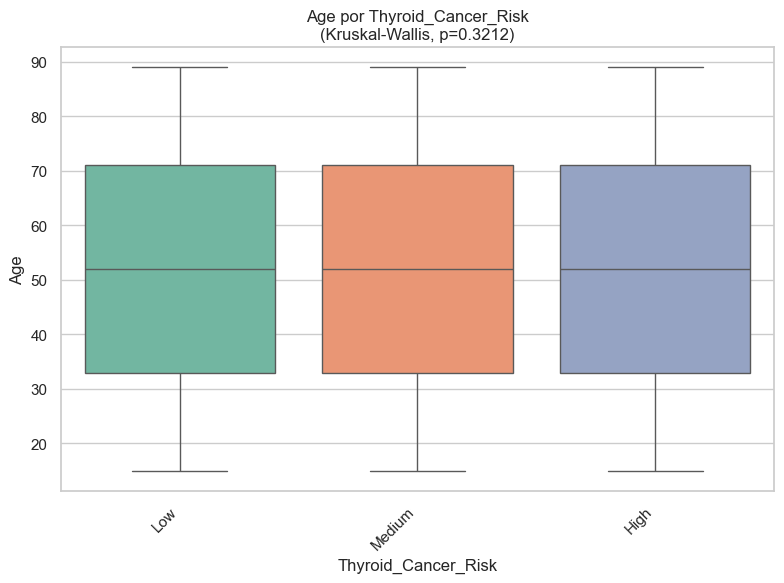

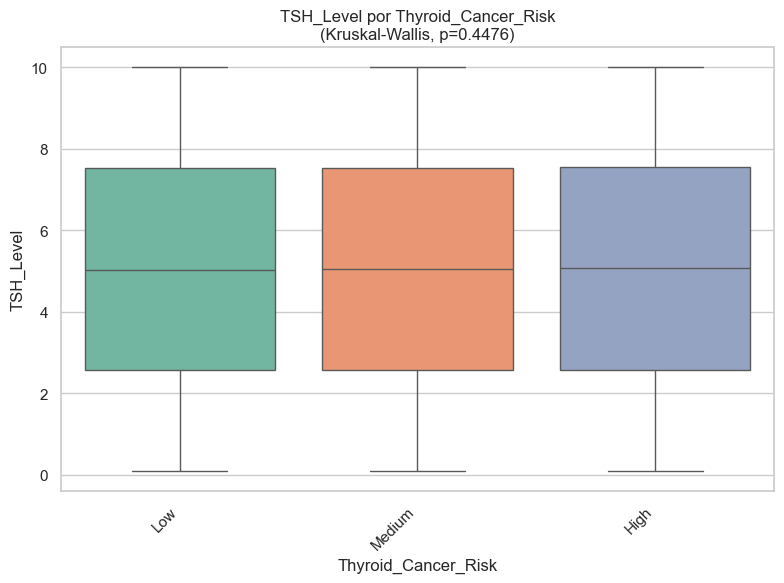

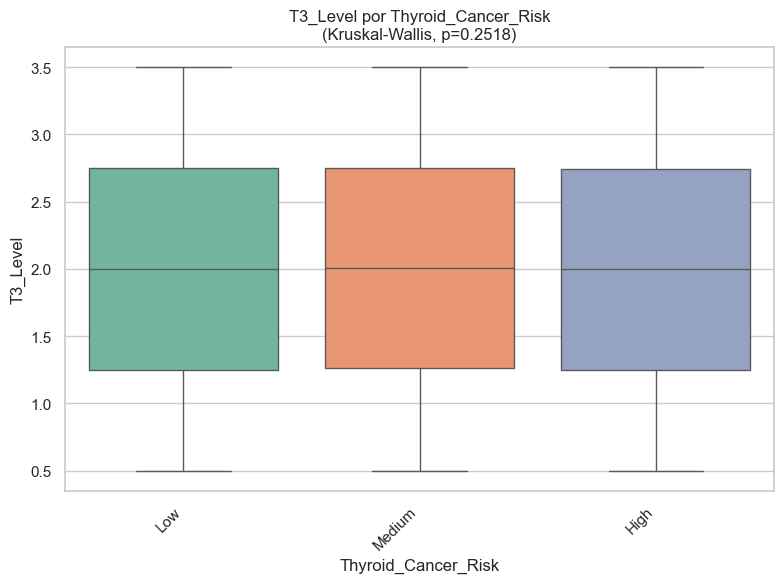

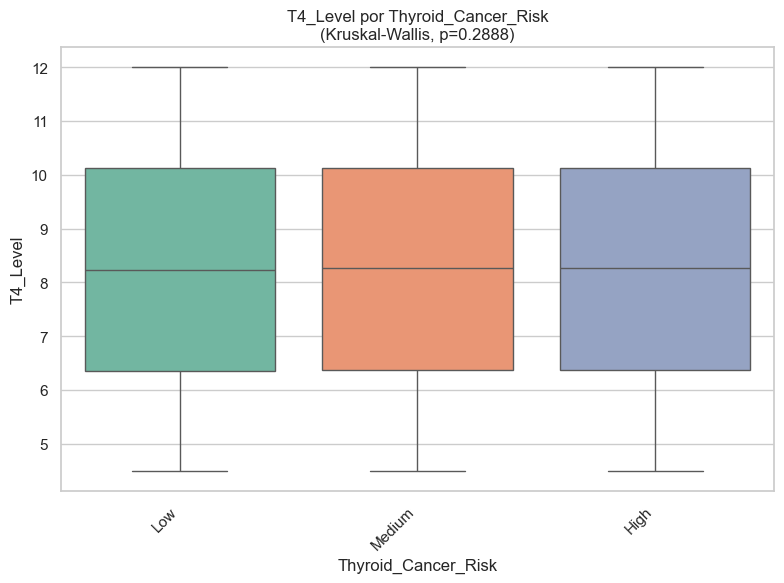

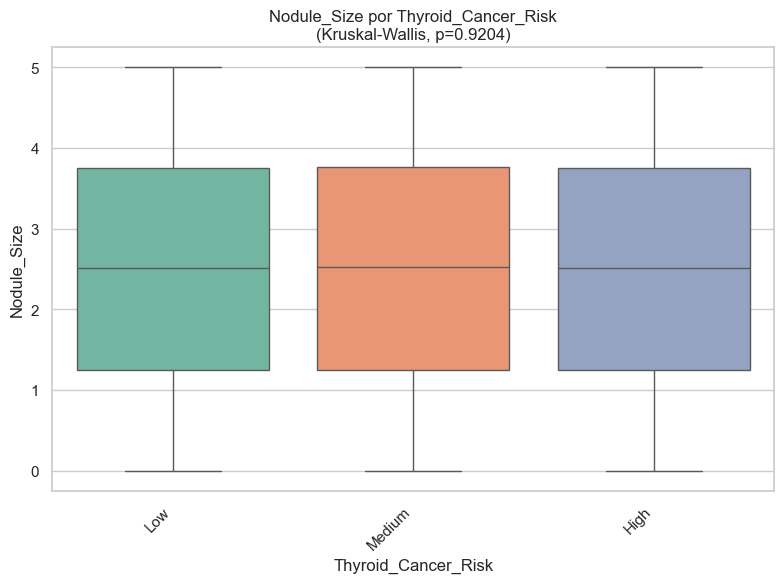

,Categórica,Numérica,Prueba,Normalidad_OK,Homocedasticidad_OK,p-Levene,Estadístico,p-valor
0,Gender,Age,Kruskal-Wallis,False,True,0.485397,0.004881,0.944301
1,Gender,TSH_Level,Kruskal-Wallis,False,True,0.484763,0.002273,0.961974
2,Gender,T3_Level,Kruskal-Wallis,False,True,0.384236,2.000556,0.157242
3,Gender,T4_Level,Kruskal-Wallis,False,True,0.664562,0.002879,0.957207
4,Gender,Nodule_Size,Kruskal-Wallis,False,True,0.794736,7.043431,0.007956
5,Country,Age,Kruskal-Wallis,False,True,0.225315,8.870927,0.449273
6,Country,TSH_Level,Kruskal-Wallis,False,True,0.488191,6.882726,0.649328
7,Country,T3_Level,Kruskal-Wallis,False,True,0.340051,11.877293,0.220316
8,Country,T4_Level,Kruskal-Wallis,False,True,0.622783,3.664433,0.932080
9,Country,Nodule_Size,Kruskal-Wallis,False,True,0.271185,4.811564,0.850416


In [28]:
analisis_bivariado_cat_num(df,categoricas,numericas)

Se usó Kruskal-Wallis porque ninguna variable numérica pasó normalidad.
Casi todas las combinaciones cumplen homocedasticidad.
La mayoría de los p-valores son altos, así que no hay diferencias fuertes entre grupos.
Gender solo muestra diferencias pequeñas en Nodule_Size.
Country y Ethnicity casi no afectan las hormonas ni el tamaño del nódulo.
Family_History muestra una leve diferencia en TSH.
Radiation_Exposure prácticamente no cambia las variables numéricas.
Iodine_Deficiency mantiene valores muy estables entre grupos.
Smoking no altera mucho TSH, T3, T4 ni Nodule_Size.
Obesity y Diabetes tampoco generan cambios marcados.
Diagnosis no muestra diferencias fuertes entre grupos numéricos.
Thyroid_Cancer_Risk casi no cambia las variables numéricas.

### Comparacion de variables con el target 

realizamos una comparacion mas detenidamente entre la variable objetivo y las demas variables para ver como se comparan entre si 


===== Análisis bivariado: Patient_ID vs Thyroid_Cancer_Risk =====



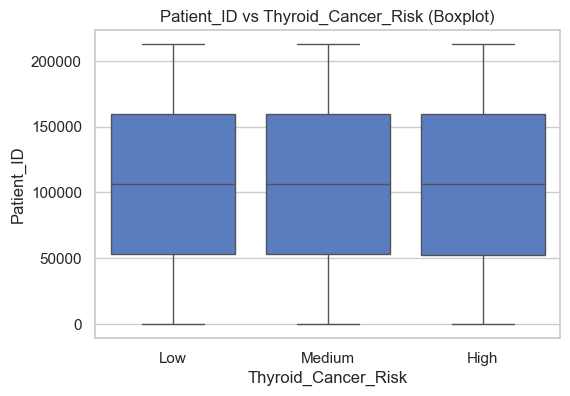


===== Análisis bivariado: Age vs Thyroid_Cancer_Risk =====



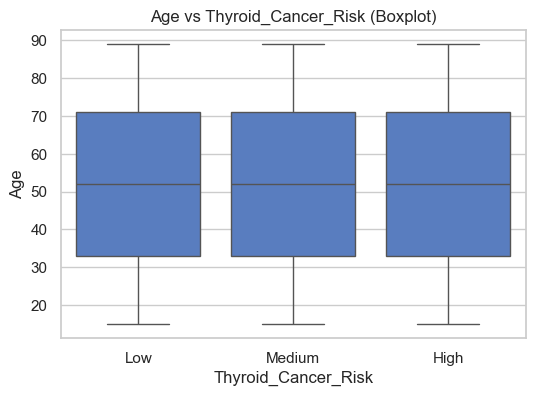


===== Análisis bivariado: TSH_Level vs Thyroid_Cancer_Risk =====



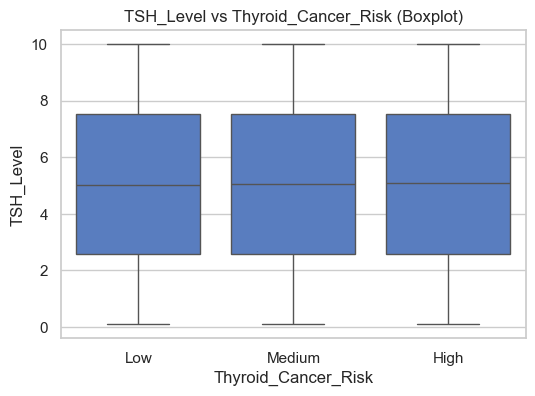


===== Análisis bivariado: T3_Level vs Thyroid_Cancer_Risk =====



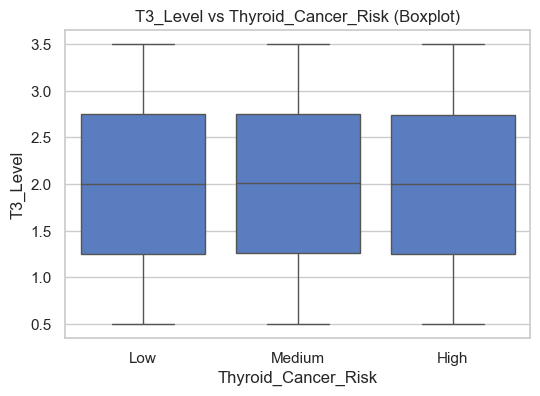


===== Análisis bivariado: T4_Level vs Thyroid_Cancer_Risk =====



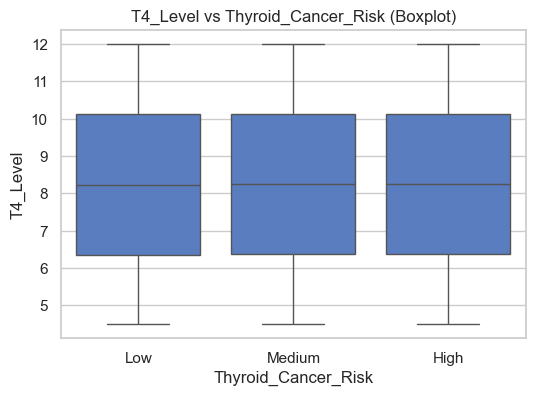


===== Análisis bivariado: Nodule_Size vs Thyroid_Cancer_Risk =====



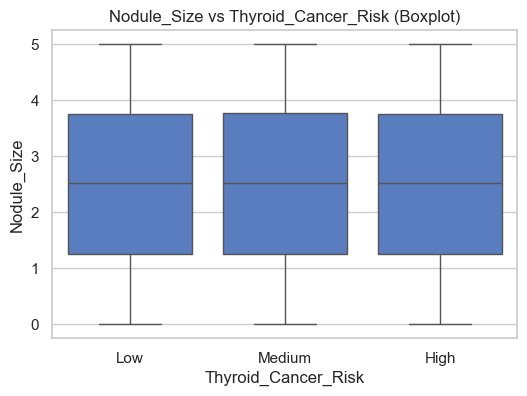

In [29]:
comparacion_numericas_target(df,'Thyroid_Cancer_Risk')

Se realizan comparaciones entre la variable objetivo y las categoricas y se examina el numero de personas que pertenecen a cada una de las categorias con respecto a las otras variables


===== Análisis bivariado: Gender vs Thyroid_Cancer_Risk =====

Frecuencias absolutas:
 Thyroid_Cancer_Risk   High    Low  Medium
Gender                                   
Female               19297  64791   43439
Male                 12606  43597   28961

Frecuencias relativas (%):
 Thyroid_Cancer_Risk  High   Low  Medium
Gender                                 
Female               0.15  0.51    0.34
Male                 0.15  0.51    0.34


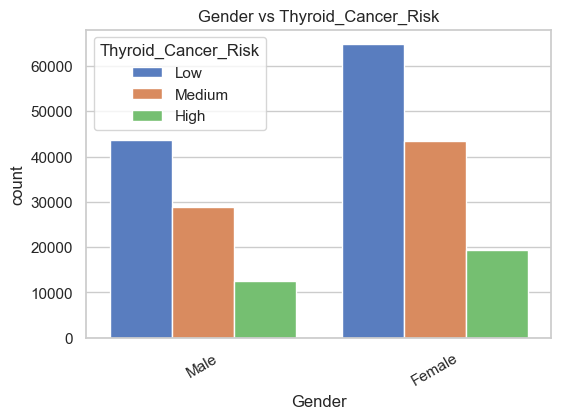

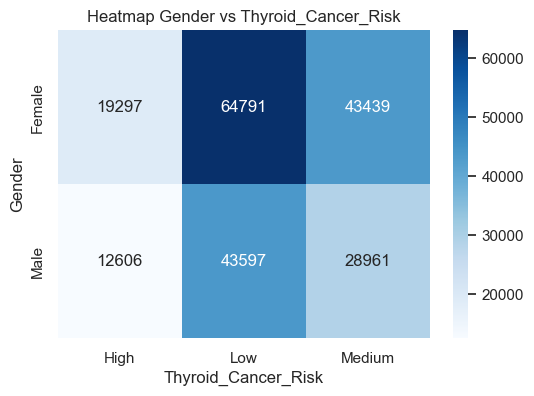


===== Análisis bivariado: Country vs Thyroid_Cancer_Risk =====

Frecuencias absolutas:
 Thyroid_Cancer_Risk   High    Low  Medium
Country                                  
Brazil                2308  11354    7751
China                 3469  17140   11369
Germany               1117   5704    3736
India                13965  17117   11414
Japan                 1697   9108    6062
Nigeria               3357  17076   11485
Russia                2226  11462    7609
South Korea           1571   7943    5451
UK                    1107   5803    3732
USA                   1086   5681    3791

Frecuencias relativas (%):
 Thyroid_Cancer_Risk  High   Low  Medium
Country                                
Brazil               0.11  0.53    0.36
China                0.11  0.54    0.36
Germany              0.11  0.54    0.35
India                0.33  0.40    0.27
Japan                0.10  0.54    0.36
Nigeria              0.11  0.53    0.36
Russia               0.10  0.54    0.36
South Korea       

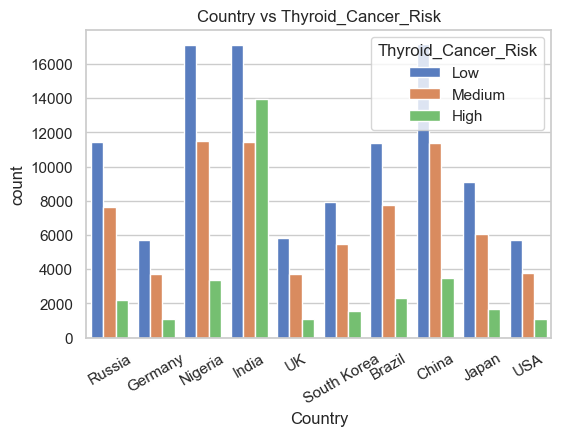

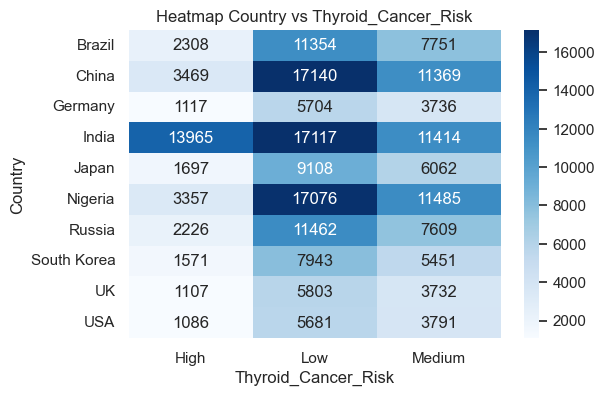


===== Análisis bivariado: Ethnicity vs Thyroid_Cancer_Risk =====

Frecuencias absolutas:
 Thyroid_Cancer_Risk   High    Low  Medium
Ethnicity                                
African               8209  20618   13587
Asian                17829  21254   14178
Caucasian             3200  36201   24268
Hispanic              1575  18270   12167
Middle Eastern        1090  12045    8200

Frecuencias relativas (%):
 Thyroid_Cancer_Risk  High   Low  Medium
Ethnicity                              
African              0.19  0.49    0.32
Asian                0.33  0.40    0.27
Caucasian            0.05  0.57    0.38
Hispanic             0.05  0.57    0.38
Middle Eastern       0.05  0.56    0.38


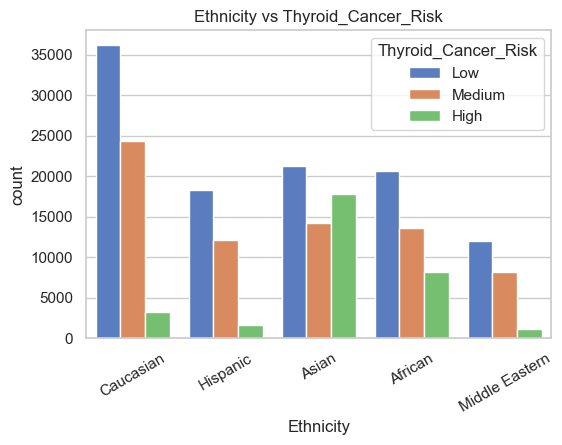

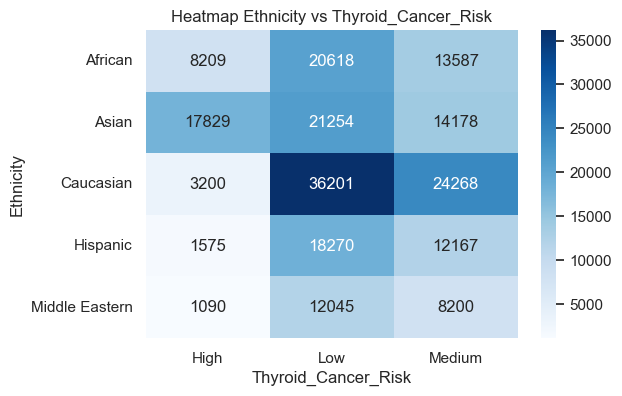


===== Análisis bivariado: Family_History vs Thyroid_Cancer_Risk =====

Frecuencias absolutas:
 Thyroid_Cancer_Risk   High    Low  Medium
Family_History                           
No                   11676  82242   54948
Yes                  20227  26146   17452

Frecuencias relativas (%):
 Thyroid_Cancer_Risk  High   Low  Medium
Family_History                         
No                   0.08  0.55    0.37
Yes                  0.32  0.41    0.27


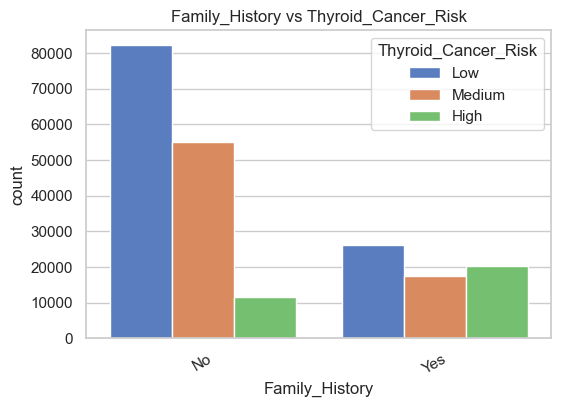

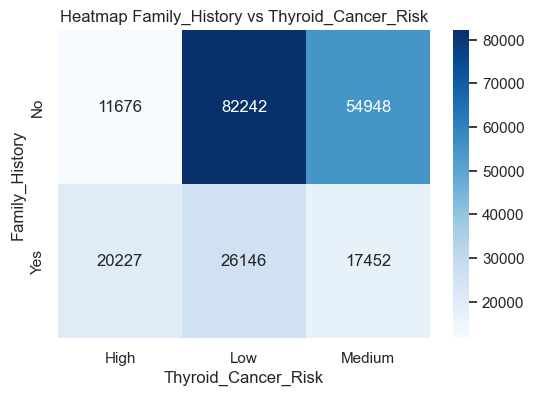


===== Análisis bivariado: Radiation_Exposure vs Thyroid_Cancer_Risk =====

Frecuencias absolutas:
 Thyroid_Cancer_Risk   High    Low  Medium
Radiation_Exposure                       
No                   22033  95171   63627
Yes                   9870  13217    8773

Frecuencias relativas (%):
 Thyroid_Cancer_Risk  High   Low  Medium
Radiation_Exposure                     
No                   0.12  0.53    0.35
Yes                  0.31  0.41    0.28


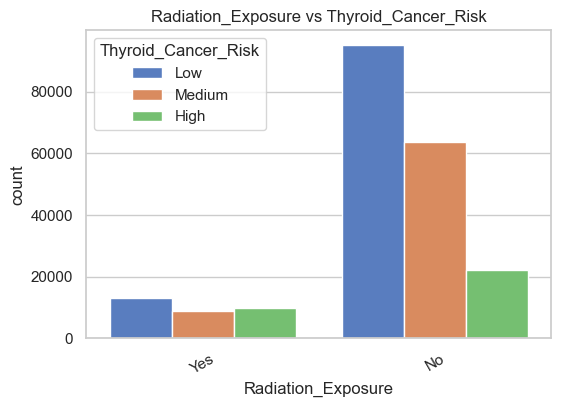

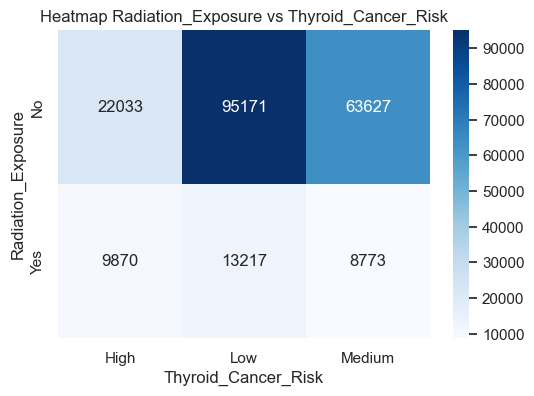


===== Análisis bivariado: Iodine_Deficiency vs Thyroid_Cancer_Risk =====

Frecuencias absolutas:
 Thyroid_Cancer_Risk   High    Low  Medium
Iodine_Deficiency                        
No                   16846  85630   57197
Yes                  15057  22758   15203

Frecuencias relativas (%):
 Thyroid_Cancer_Risk  High   Low  Medium
Iodine_Deficiency                      
No                   0.11  0.54    0.36
Yes                  0.28  0.43    0.29


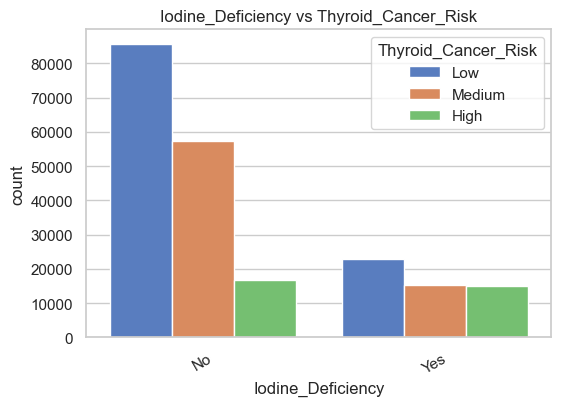

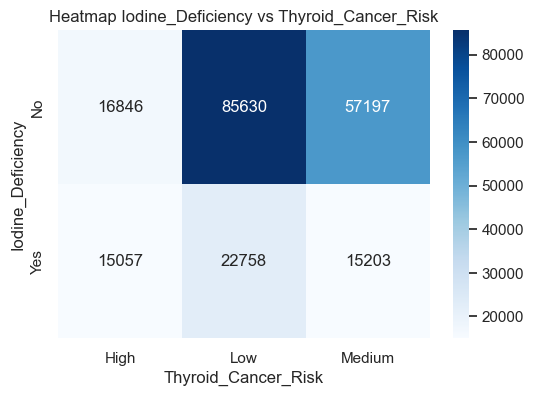


===== Análisis bivariado: Smoking vs Thyroid_Cancer_Risk =====

Frecuencias absolutas:
 Thyroid_Cancer_Risk   High    Low  Medium
Smoking                                  
No                   25534  86658   58068
Yes                   6369  21730   14332

Frecuencias relativas (%):
 Thyroid_Cancer_Risk  High   Low  Medium
Smoking                                
No                   0.15  0.51    0.34
Yes                  0.15  0.51    0.34


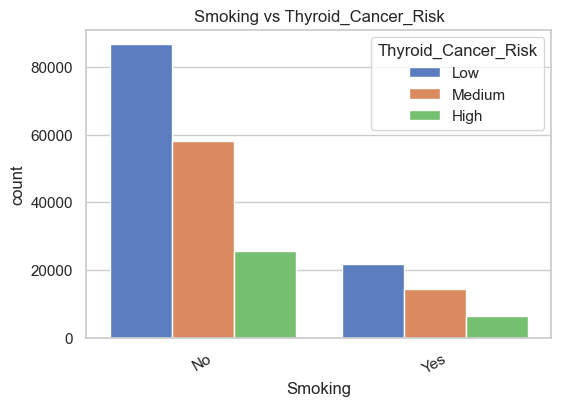

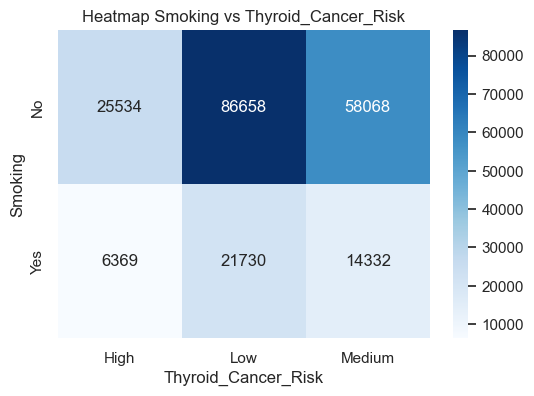


===== Análisis bivariado: Obesity vs Thyroid_Cancer_Risk =====

Frecuencias absolutas:
 Thyroid_Cancer_Risk   High    Low  Medium
Obesity                                  
No                   22430  75766   50609
Yes                   9473  32622   21791

Frecuencias relativas (%):
 Thyroid_Cancer_Risk  High   Low  Medium
Obesity                                
No                   0.15  0.51    0.34
Yes                  0.15  0.51    0.34


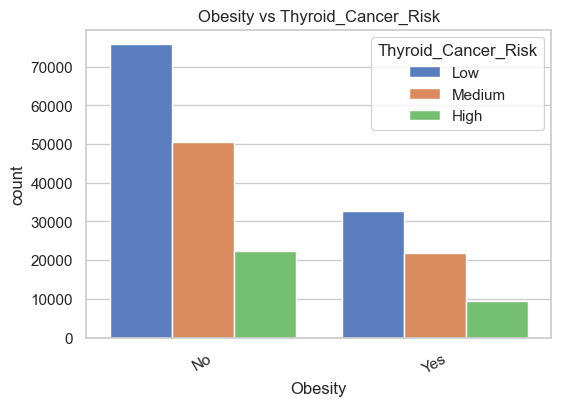

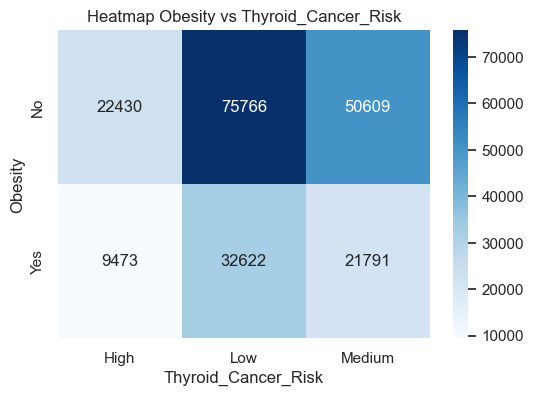


===== Análisis bivariado: Diabetes vs Thyroid_Cancer_Risk =====

Frecuencias absolutas:
 Thyroid_Cancer_Risk   High    Low  Medium
Diabetes                                 
No                   25497  86602   57999
Yes                   6406  21786   14401

Frecuencias relativas (%):
 Thyroid_Cancer_Risk  High   Low  Medium
Diabetes                               
No                   0.15  0.51    0.34
Yes                  0.15  0.51    0.34


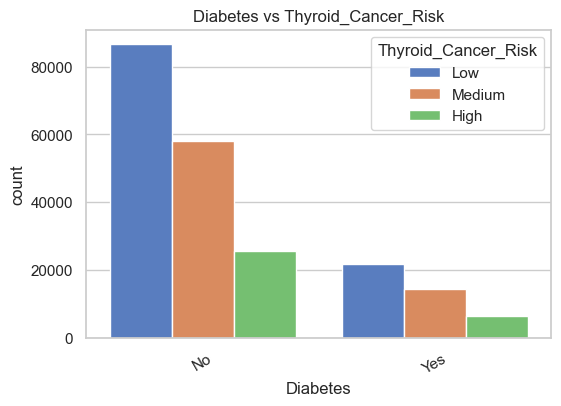

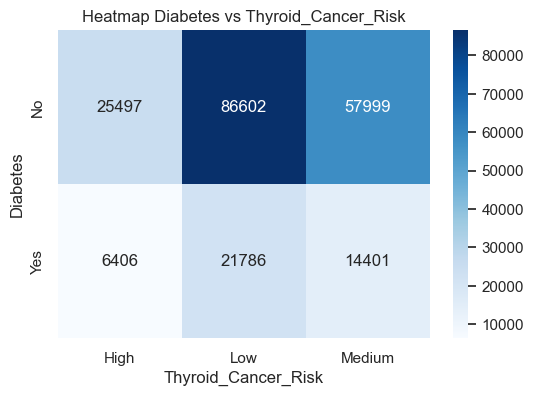


===== Análisis bivariado: Diagnosis vs Thyroid_Cancer_Risk =====

Frecuencias absolutas:
 Thyroid_Cancer_Risk   High    Low  Medium
Diagnosis                                
Benign                9564  92153   61479
Malignant            22339  16235   10921

Frecuencias relativas (%):
 Thyroid_Cancer_Risk  High   Low  Medium
Diagnosis                              
Benign               0.06  0.56    0.38
Malignant            0.45  0.33    0.22


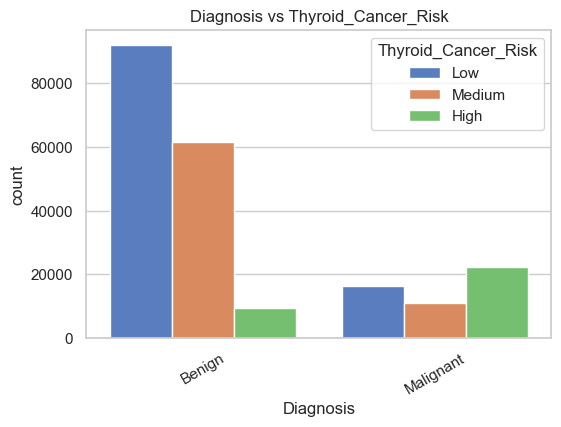

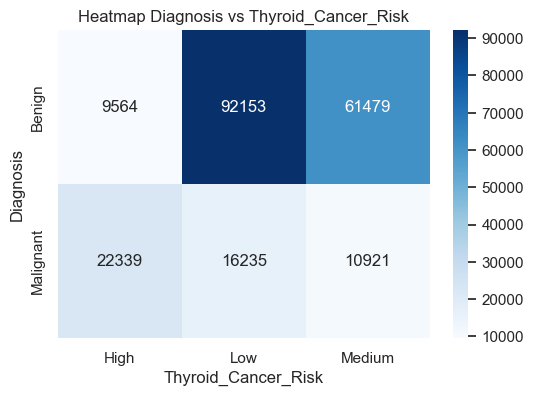

In [30]:
comparacion_categoricas_target(df,'Thyroid_Cancer_Risk')

Gender: hombres y mujeres tienen exactamente la misma distribución de riesgo.
Country: casi todos los países tienen patrones similares, excepto India, donde el riesgo High es mucho más común.
Ethnicity: los asiáticos muestran más riesgo High; caucásicos e hispanos tienen más casos Low.
Family_History: tener historial familiar aumenta mucho la proporción de riesgo High.
Radiation_Exposure: la exposición a radiación sube notablemente el riesgo High.
Iodine_Deficiency: la deficiencia de yodo también incrementa el riesgo High.
Smoking: fumar no cambia la distribución del riesgo.
Obesity: la obesidad tampoco afecta el riesgo.
Diabetes: la diabetes no muestra cambios en el riesgo.
Diagnosis: los malignos tienen una proporción muy alta de riesgo High, como era de esperar.

## Analisis de correlacion

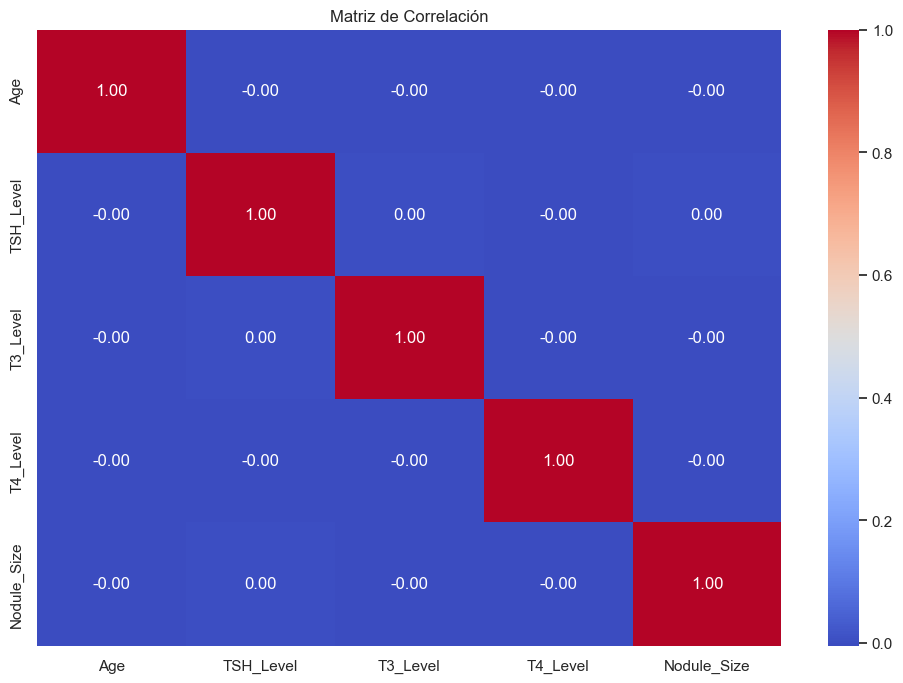

In [31]:
corr=df[numericas].corr(method='spearman')
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación')
plt.show()

Podemos observar que no hay correlaciones fuertes entre las variables numericas 

In [32]:
corr_cat = categorical_corr_matrix(df)

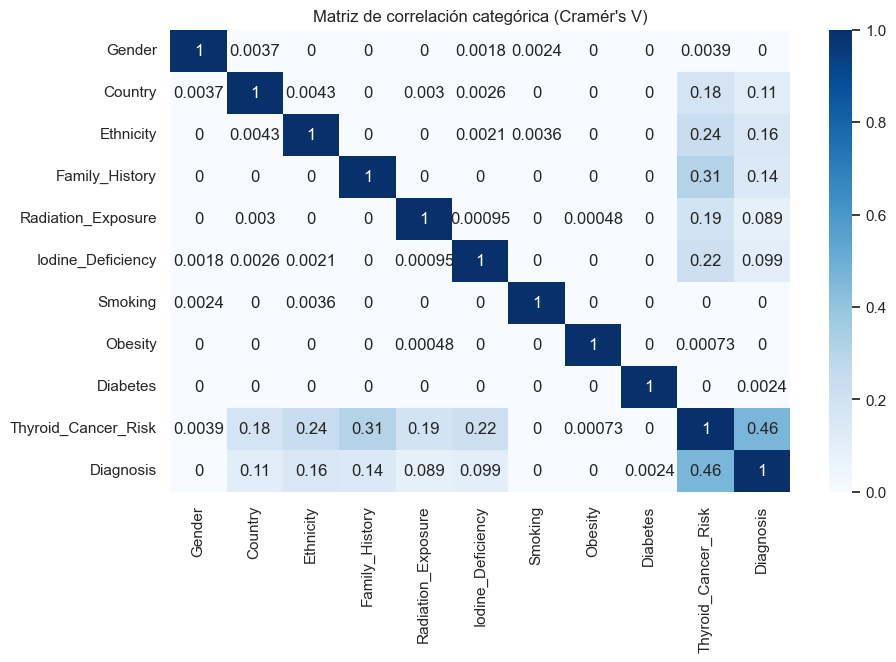

In [33]:
plt.figure(figsize=(10,6))
sns.heatmap(corr_cat, annot=True, cmap="Blues", vmin=0, vmax=1)
plt.title("Matriz de correlación categórica (Cramér's V)")
plt.show()

## Observaciones


 La mayoría de las variables tienen correlaciones casi nulas entre sí; el dataset es muy independiente en sus categorías.

 Diagnosis es la única variable que se relaciona moderadamente con Thyroid_Cancer_Risk (0.46).

 Family_History es la categoría más asociada con el riesgo (0.31), más que cualquier factor ambiental.

 La influencia de Ethnicity en el riesgo (0.24) es mayor que la de Country (0.18).

 Tabaquismo, obesidad y diabetes prácticamente no se relacionan con el riesgo en este dataset.

 Radiation_Exposure tiene una correlación baja pero visible con el riesgo (0.19).

 Gender prácticamente no aporta información sobre el riesgo (0.0039).

 Las correlaciones internas entre factores de salud (obesidad, diabetes, smoking) son casi cero, indicando independencia.

 La deficiencia de yodo se asocia un poco con el riesgo (0.22), más que el tabaquismo o la obesidad.

 El patrón general sugiere que los factores clínicos pesan más que los sociodemográficos.